# P&B scale-free impact workbench

This notebook asks whether one response law can describe corrected BTCUSDT event bars from 200 to 8,000 events. It deliberately distinguishes two meanings of stability:

1. **aggregation-scale stability:** one shape and power-law rescaling work across event counts;
2. **calendar-time stability:** parameters calibrated in the past continue to work in later market regimes.

The notebook reads compact result tables. Changing the controls changes the views but does not refit the models or rescan the event data. June–August 2026 remain untouched holdout months.

## Variables and nested models

For a completed event bar,

$$
z=\frac{|Q|}{V},\qquad
a=\frac{V}{V_{24h}},\qquad
y=\frac{\operatorname{sign}(Q)r}{\sigma_{24h}}.
$$

The original P&B pressure coordinate is therefore

$$
za=\frac{|Q|}{V_{24h}}.
$$

Every candidate uses event-count power laws

$$
\mathcal Q_N=\mathcal Q_{1000}\left(\frac{N}{1000}\right)^\xi,
\qquad
\mathcal R_{N,s}=\mathcal R_{1000,s}\left(\frac{N}{1000}\right)^\psi,
$$

and the response shape

$$
F_p(u)=\frac{u^p}{(1+u^\alpha)^{\beta/\alpha}}.
$$

The models are nested:

- `pb_classic`: $u=za/\mathcal Q_N$ and $p=1$;
- `pb_activity`: $u=za^\gamma/\mathcal Q_N$ with fitted $\gamma$, while $p=1$;
- `pb_activity_vertical`: $\widehat y=\mathcal R_{N,s}\widetilde a^\delta
  F(u)$, where $\widetilde a$ is activity divided by its training-fitted normal
  level at that event scale. The current activity model is nested at $\delta=0$;
- `pb_activity_beta`: the high-pressure concavity parameter obeys
  $\operatorname{logit}\beta(\widetilde a)=b_0+b_1\log\widetilde a$;
- `pb_activity_generalised`: both $\gamma$ and $p$ are fitted;
- `independent_power_surface`: the existing $Az^pa^q$ surface fitted separately to every scale and side. This is the flexible benchmark, not a scale-free model.

Buy and sell observations share the shape and exponents, but have separate response levels $\mathcal R_{1000,s}$.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_activity_beta_extension_v3'
CONFIG = REPO / 'alpha-search' / 'configs' / 'pb_activity_beta_extension_v3.json'
config = json.loads(CONFIG.read_text())
manifest = json.loads((RESULTS / 'run_manifest.json').read_text())
fits = pl.read_csv(RESULTS / 'scaling_fits.csv', infer_schema_length=None)
benchmark_fits = pl.read_csv(
    RESULTS / 'independent_surface_fits.csv', infer_schema_length=None
)
evaluation = pl.read_csv(
    RESULTS / 'scaling_evaluation.csv', infer_schema_length=None
)
collapsed = pl.read_csv(RESULTS / 'collapsed_cells.csv', infer_schema_length=None)
evolution = pl.read_csv(RESULTS / 'market_evolution.csv')
scaling_cells = pl.read_csv(RESULTS / 'scaling_cells.csv', infer_schema_length=None)

ROLLING_RESULTS = REPO / 'alpha-search' / 'reports' / 'rolling_pb_residual_response_v2'
ROLLING_CONFIG = REPO / 'alpha-search' / 'configs' / 'rolling_pb_residual_response_v2.json'
rolling_config = json.loads(ROLLING_CONFIG.read_text())
rolling_fits = pl.read_csv(ROLLING_RESULTS / 'rolling_fits.csv')
monthly_ic = pl.read_csv(ROLLING_RESULTS / 'monthly_residual_ic.csv')
residual_ic_summary = pl.read_csv(ROLLING_RESULTS / 'residual_ic_summary.csv')
residual_quantiles = pl.read_csv(
    ROLLING_RESULTS / 'monthly_residual_quantiles.csv'
)

ACTIVITY_DIAGNOSTICS = (
    REPO / 'alpha-search' / 'reports' / 'pb_residual_activity_diagnostics_v1'
)
cell_activity = pl.read_csv(
    ACTIVITY_DIAGNOSTICS / 'cell_residual_activity.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
bar_activity_curves = pl.read_csv(
    ACTIVITY_DIAGNOSTICS / 'bar_activity_curves.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
bar_activity_grid = pl.read_csv(
    ACTIVITY_DIAGNOSTICS / 'bar_pressure_activity_grid.csv',
    infer_schema_length=None,
).with_columns(pl.col('fold').cast(pl.Utf8))
monthly_activity = pl.read_csv(
    ACTIVITY_DIAGNOSTICS / 'monthly_activity_relations.csv',
    infer_schema_length=None,
).with_columns(pl.col('fold').cast(pl.Utf8))

LAG_RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_lagged_impact_extension_v4'
LAG_CONFIG = REPO / 'alpha-search' / 'configs' / 'pb_lagged_impact_extension_v4.json'
lag_config = json.loads(LAG_CONFIG.read_text())
lag_evaluation = pl.read_csv(
    LAG_RESULTS / 'oos_evaluation.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
lag_coefficients = pl.read_csv(
    LAG_RESULTS / 'lag_coefficients.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
lag_curves = pl.read_csv(
    LAG_RESULTS / 'lag_diagnostic_curves.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
calibration_ledger = pl.read_csv(
    LAG_RESULTS / 'calibration_ledger.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
MODEL_LABELS = {
    'pb_classic': 'Original P&B coordinate',
    'pb_activity': 'Activity-adjusted P&B',
    'pb_activity_vertical': 'Activity-adjusted with vertical term',
    'pb_activity_beta': 'Activity-dependent concavity',
    'pb_activity_generalised': 'Activity-adjusted, free central exponent',
    'independent_power_surface': 'Independent power surfaces',
}
MODEL_COLOURS = {
    'pb_classic': '#64748b',
    'pb_activity': '#2563eb',
    'pb_activity_vertical': '#7c3aed',
    'pb_activity_beta': '#db2777',
    'pb_activity_generalised': '#d97706',
    'independent_power_surface': '#13795b',
}

def horizon_label(seconds):
    seconds = int(seconds)
    if seconds < 60:
        return f'{seconds}s'
    minutes = seconds / 60
    return f'{minutes:g}m'

## Manual controls

In [2]:
SAMPLE = 'full_history'          # full_history or post_2021
FAMILY = 'pb_activity'           # one of the five P&B families above
OOS_FOLD = '3'                   # 1=2023, 2=2024, 3=2025, 4=Jan-May 2026
DISPLAY_SCALES = [200, 500, 1000, 2000, 4000, 8000]
EARLY_CUTOFF = '2021-01-01'      # recorded here to keep the sensitivity explicit
IC_TRAINING_WINDOW = 12           # 6 or 12 months
IC_HORIZON_SECONDS = 15 * 60       # 30s, 1m, 2m, 5m, 10m, 15m, 30m, or 60m
IC_EVENT_SIZE = 8000              # selected term-structure and monthly-IC view
IC_SIDE = 'all'                    # all, buy, or sell
RESIDUAL_VARIANT = 'conditional_z' # conditional_z or scaled
DIAGNOSTIC_SAMPLE = SAMPLE
DIAGNOSTIC_FOLD = OOS_FOLD
DIAGNOSTIC_SIDE = 'all'             # all, buy, or sell
DIAGNOSTIC_RESIDUAL = 'scaled_residual'  # scaled_residual or raw_residual
DIAGNOSTIC_EVENT_SIZE = 1000        # detailed pressure/activity heatmap
LAG_MODEL = 'lag_impact'             # lag_impact, lag_activity, or lag_activity_duration

assert SAMPLE in {'full_history', 'post_2021'}
assert FAMILY in set(config['model_families'])
assert OOS_FOLD in {'1', '2', '3', '4'}
assert set(DISPLAY_SCALES).issubset(set(config['event_sizes']))
assert IC_TRAINING_WINDOW in {6, 12}
assert IC_HORIZON_SECONDS in set(rolling_config['future_horizons_seconds'])
assert IC_EVENT_SIZE in set(DISPLAY_SCALES)
assert IC_SIDE in {'all', 'buy', 'sell'}
assert RESIDUAL_VARIANT in {'conditional_z', 'scaled'}
assert DIAGNOSTIC_SAMPLE in {'full_history', 'post_2021'}
assert DIAGNOSTIC_FOLD in {'1', '2', '3', '4'}
assert DIAGNOSTIC_SIDE in {'all', 'buy', 'sell'}
assert DIAGNOSTIC_RESIDUAL in {'scaled_residual', 'raw_residual'}
assert DIAGNOSTIC_EVENT_SIZE in set(DISPLAY_SCALES)
assert LAG_MODEL in {'lag_impact', 'lag_activity', 'lag_activity_duration'}

fold_definition = next(
    row for row in config['folds'] if str(row['fold']) == OOS_FOLD
)
display(Markdown(
    f"**Selected view:** `{SAMPLE}`, `{FAMILY}`. Fold {OOS_FOLD} is trained "
    f"strictly before `{fold_definition['train_end']}` and tested from "
    f"`{fold_definition['test_start']}` to `{fold_definition['test_end']}`."
))

**Selected view:** `full_history`, `pb_activity`. Fold 3 is trained strictly before `2025-01-01` and tested from `2025-01-01` to `2026-01-01`.

## How different is the early market?

Fixed event counts do not represent fixed clock durations. The graph below is a direct descriptive reason to test the early-period exclusion rather than silently discarding those observations.

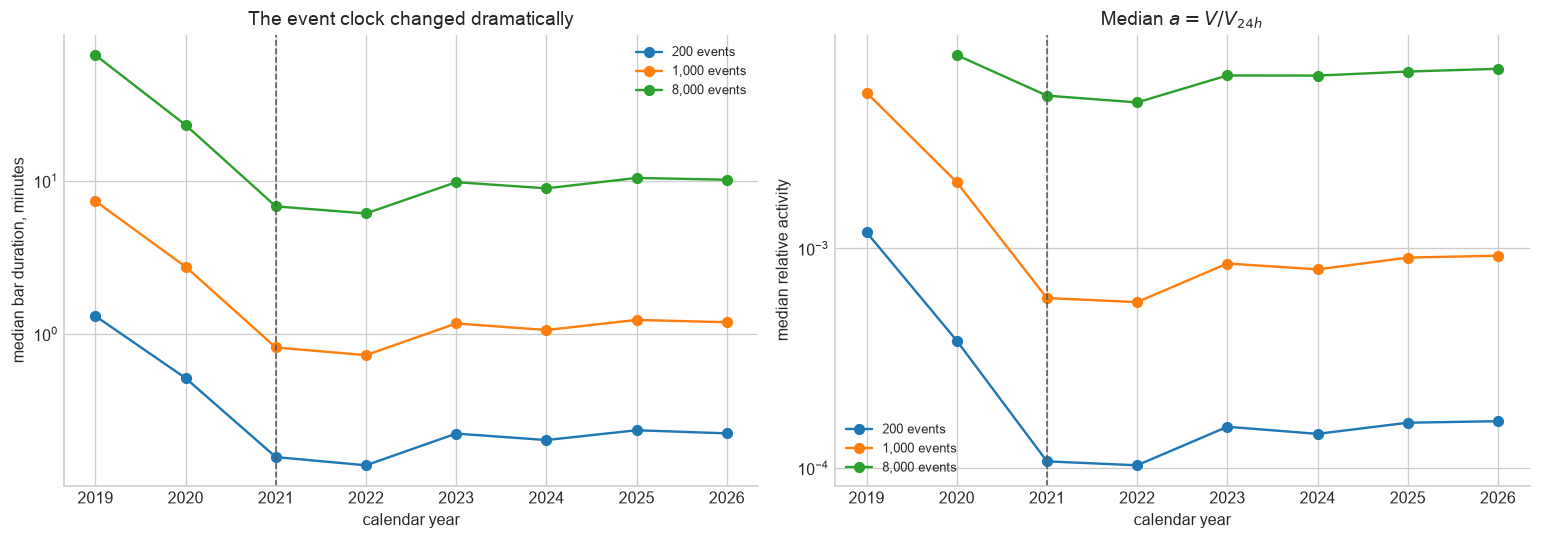

year,bars,median_duration_seconds,median_relative_activity,median_relative_imbalance,median_abs_normalised_impact
i64,i64,f64,f64,f64,f64
2019,14378,441.6515,0.005124,0.124003,0.044115
2020,142215,164.827,0.002003,0.188153,0.029504
2021,538155,49.001,0.000594,0.214003,0.016133
2022,523199,43.69,0.000569,0.225126,0.015729
2023,350859,70.299,0.000854,0.221586,0.018956
2024,384796,63.711,0.000803,0.238022,0.01946
2025,335554,74.147,0.000908,0.23642,0.020566
2026,133456,71.612,0.000927,0.220322,0.020648


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for n_events in [200, 1000, 8000]:
    part = evolution.filter(pl.col('n_events') == n_events).sort('year')
    axes[0].plot(
        part['year'], part['median_duration_seconds'] / 60,
        'o-', label=f'{n_events:,} events'
    )
    axes[1].plot(
        part['year'], part['median_relative_activity'],
        'o-', label=f'{n_events:,} events'
    )
axes[0].set_ylabel('median bar duration, minutes')
axes[0].set_xlabel('calendar year')
axes[0].set_yscale('log')
axes[0].set_title('The event clock changed dramatically')
axes[1].set_ylabel('median relative activity')
axes[1].set_xlabel('calendar year')
axes[1].set_yscale('log')
axes[1].set_title(r'Median $a=V/V_{24h}$')
for ax in axes:
    ax.axvline(2021, color='0.35', ls='--', lw=1)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(
    evolution.filter(pl.col('n_events') == 1000)
    .sort('year')
    .select(
        'year', 'bars', 'median_duration_seconds',
        'median_relative_activity', 'median_relative_imbalance',
        'median_abs_normalised_impact'
    )
)

## Full-sample fitted parameters

In [4]:
parameter_columns = [
    'sample', 'family', 'q_exponent_xi', 'r_exponent_psi',
    'activity_exponent_gamma', 'central_exponent_p',
    'activity_vertical_exponent_delta', 'activity_scale_exponent_eta',
    'shape_beta_activity_slope',
    'shape_alpha', 'shape_beta', 'tail_exponent', 'cell_rmse'
]
display(
    fits.filter(pl.col('fold') == 'full_fit')
    .select(parameter_columns)
    .sort(['sample', 'cell_rmse'])
)

sample,family,q_exponent_xi,r_exponent_psi,activity_exponent_gamma,central_exponent_p,activity_vertical_exponent_delta,activity_scale_exponent_eta,shape_beta_activity_slope,shape_alpha,shape_beta,tail_exponent,cell_rmse
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""full_history""","""pb_activity_vertical""",-0.229498,0.560566,0.043887,1.0,0.438407,1.00726,0.0,2.154913,0.388418,0.611582,0.001291
"""full_history""","""pb_activity_beta""",0.319377,0.595355,0.544902,1.0,0.0,1.00726,-0.328598,1.393729,0.454174,0.545826,0.00134
"""full_history""","""pb_activity_generalised""",0.420846,0.638308,0.58881,1.123202,0.0,1.00726,0.0,0.883093,0.455846,0.667356,0.001366
"""full_history""","""pb_activity""",0.413219,0.632451,0.588704,1.0,0.0,1.00726,0.0,1.623068,0.277225,0.722775,0.001367
"""full_history""","""pb_classic""",0.988169,0.750175,1.0,1.0,0.0,1.00726,0.0,1.768242,0.460406,0.539594,0.004183
"""post_2021""","""pb_activity_beta""",-0.8566,0.072344,6.2124e-11,1.0,0.0,1.021128,-0.611924,0.204428,0.361301,0.638699,0.001386
"""post_2021""","""pb_activity_vertical""",-0.349267,0.511452,5.3255e-16,1.0,0.450859,1.021128,0.0,3.110666,0.303562,0.696438,0.001436
"""post_2021""","""pb_activity_generalised""",0.392544,0.651917,0.553502,1.001554,0.0,1.021128,0.0,1.866071,0.247039,0.754515,0.001528
"""post_2021""","""pb_activity""",0.392122,0.651589,0.55349,1.0,0.0,1.021128,0.0,1.893041,0.244796,0.755204,0.001528


## The actual collapse

Each point is one relative-imbalance by relative-activity cell. A convincing collapse should remove systematic separation by event count. Buy and sell levels have already been divided by their fitted side-specific response scales.

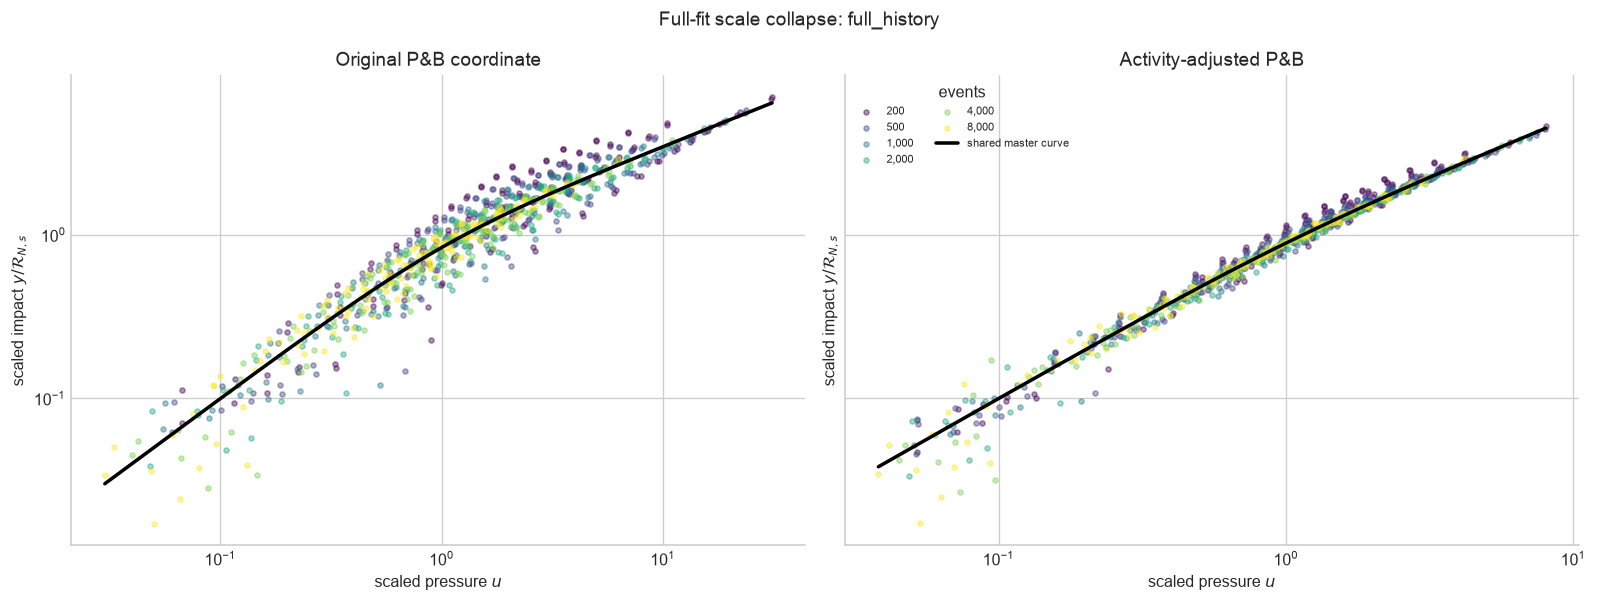

In [5]:
def show_collapse(sample, family, ax):
    view = collapsed.filter(
        (pl.col('sample') == sample) &
        (pl.col('family') == family) &
        pl.col('n_events').is_in(DISPLAY_SCALES)
    )
    cmap = plt.get_cmap('viridis')
    for index, n_events in enumerate(DISPLAY_SCALES):
        part = view.filter(
            (pl.col('n_events') == n_events) &
            (pl.col('scaled_observed_impact') > 0)
        )
        ax.scatter(
            part['scaled_pressure'], part['scaled_observed_impact'],
            s=10, alpha=.42, color=cmap(index / max(1, len(DISPLAY_SCALES)-1)),
            label=f'{n_events:,}'
        )
    positive = view.filter(pl.col('scaled_observed_impact') > 0)
    grid = np.geomspace(
        positive['scaled_pressure'].min(), positive['scaled_pressure'].max(), 500
    )
    fit = fits.filter(
        (pl.col('sample') == sample) &
        (pl.col('fold') == 'full_fit') &
        (pl.col('family') == family)
    ).row(0, named=True)
    if family == 'pb_activity_beta':
        beta_fraction = fit['shape_beta'] / fit['central_exponent_p']
        beta_logit = np.log(beta_fraction / (1-beta_fraction))
        for ell, style, label in [
            (-1.0, '--', 'low relative activity'),
            (0.0, '-', 'normal relative activity'),
            (1.0, ':', 'high relative activity'),
        ]:
            local_beta = fit['central_exponent_p'] / (
                1 + np.exp(-(
                    beta_logit + fit['shape_beta_activity_slope'] * ell
                ))
            )
            curve = grid ** fit['central_exponent_p'] / (
                1 + grid ** fit['shape_alpha']
            ) ** (local_beta / fit['shape_alpha'])
            ax.plot(grid, curve, color='black', ls=style, lw=1.8, label=label)
    else:
        curve = grid ** fit['central_exponent_p'] / (
            1 + grid ** fit['shape_alpha']
        ) ** (fit['shape_beta'] / fit['shape_alpha'])
        ax.plot(grid, curve, color='black', lw=2.2, label='shared master curve')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'scaled pressure $u$')
    ax.set_ylabel(r'scaled impact $y/\mathcal{R}_{N,s}$')
    ax.set_title(MODEL_LABELS[family])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3), sharey=True)
show_collapse(SAMPLE, 'pb_classic', axes[0])
show_collapse(SAMPLE, FAMILY, axes[1])
axes[1].legend(title='events', fontsize=7, ncol=2)
fig.suptitle(f'Full-fit scale collapse: {SAMPLE}')
plt.tight_layout()
plt.show()

## How much flexibility is needed?

In [6]:
summary = (
    evaluation.filter(
        (pl.col('split') == 'test') &
        (pl.col('n_events') == 'all') &
        (pl.col('side') == 'all')
    )
    .group_by('sample', 'family')
    .agg(
        pl.col('cell_rmse').mean().alias('mean_oos_rmse'),
        pl.col('cell_rmse').median().alias('median_oos_rmse'),
        pl.col('cell_rmse').max().alias('worst_oos_rmse'),
        pl.col('residual_log_activity_correlation').mean()
        .alias('mean_residual_activity_correlation'),
    )
    .sort(['sample', 'mean_oos_rmse'])
)
display(summary)

train_summary = evaluation.filter(
    (pl.col('split') == 'train') &
    (pl.col('fold') == 'full_fit') &
    (pl.col('n_events') == 'all') &
    (pl.col('side') == 'all')
).select(
    'sample', 'family',
    pl.col('cell_rmse').alias('full_fit_rmse'),
    pl.col('residual_log_activity_correlation')
    .alias('full_fit_residual_activity_correlation')
).sort(['sample', 'full_fit_rmse'])
display(train_summary)

sample,family,mean_oos_rmse,median_oos_rmse,worst_oos_rmse,mean_residual_activity_correlation
str,str,f64,f64,f64,f64
"""full_history""","""independent_power_surface""",0.004299,0.004784,0.005752,-0.455571
"""full_history""","""pb_activity_vertical""",0.004303,0.004687,0.005655,-0.496274
"""full_history""","""pb_activity_beta""",0.004329,0.004715,0.005673,-0.501239
"""full_history""","""pb_activity""",0.004342,0.004754,0.005689,-0.49886
"""full_history""","""pb_activity_generalised""",0.004343,0.004755,0.00569,-0.496471
…,…,…,…,…,…
"""post_2021""","""pb_activity_vertical""",0.003968,0.004195,0.005273,-0.460344
"""post_2021""","""pb_activity_beta""",0.00397,0.004262,0.005251,-0.42508
"""post_2021""","""pb_activity""",0.004035,0.004255,0.005357,-0.453458


sample,family,full_fit_rmse,full_fit_residual_activity_correlation
str,str,f64,f64
"""full_history""","""independent_power_surface""",0.001239,-0.049414
"""full_history""","""pb_activity_vertical""",0.001291,-0.244888
"""full_history""","""pb_activity_beta""",0.00134,-0.254415
"""full_history""","""pb_activity_generalised""",0.001366,-0.24131
"""full_history""","""pb_activity""",0.001367,-0.245447
…,…,…,…
"""post_2021""","""pb_activity_beta""",0.001386,-0.198168
"""post_2021""","""pb_activity_vertical""",0.001436,-0.270336
"""post_2021""","""pb_activity_generalised""",0.001528,-0.250476


## Chronological out-of-period comparison

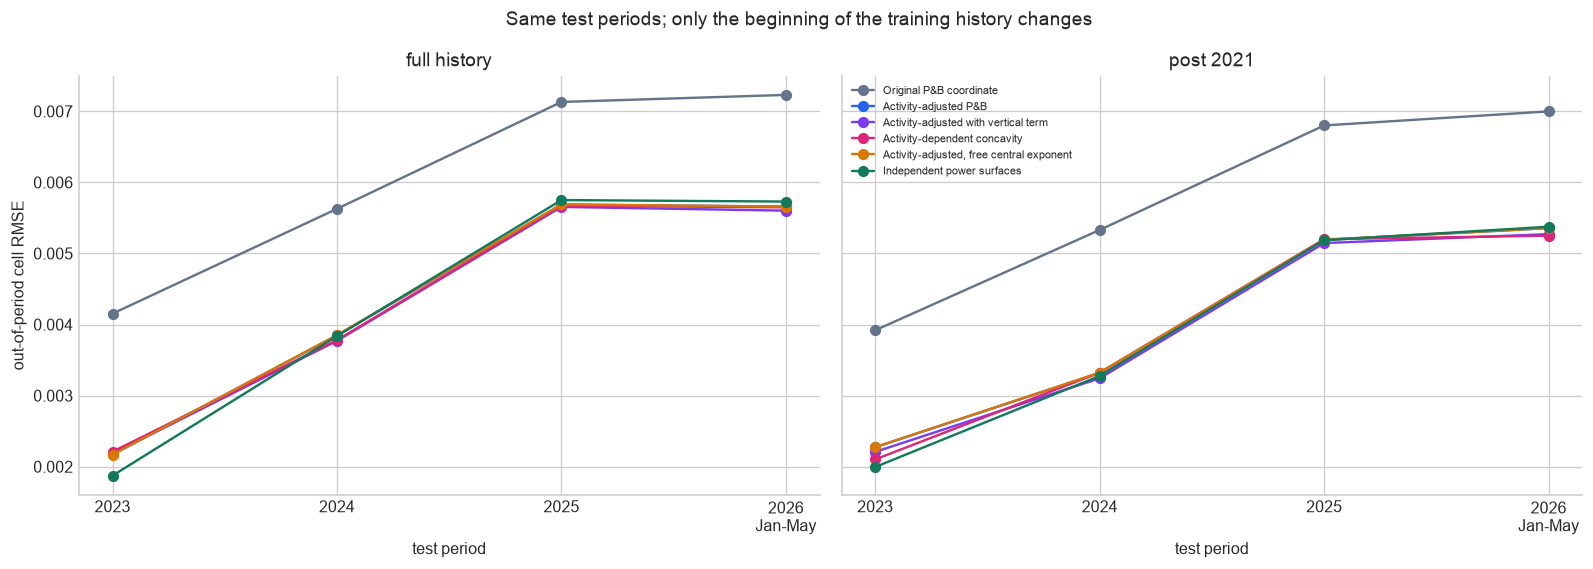

In [7]:
oos = evaluation.filter(
    (pl.col('split') == 'test') &
    (pl.col('n_events') == 'all') &
    (pl.col('side') == 'all')
).with_columns(pl.col('fold').cast(pl.Int64).alias('fold_number'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharey=True)
for ax, sample in zip(axes, ['full_history', 'post_2021']):
    for family in MODEL_LABELS:
        part = oos.filter(
            (pl.col('sample') == sample) & (pl.col('family') == family)
        ).sort('fold_number')
        ax.plot(
            part['fold_number'], part['cell_rmse'], 'o-',
            color=MODEL_COLOURS[family], label=MODEL_LABELS[family]
        )
    ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026\nJan-May'])
    ax.set_xlabel('test period')
    ax.set_title(sample.replace('_', ' '))
axes[0].set_ylabel('out-of-period cell RMSE')
axes[1].legend(fontsize=7)
fig.suptitle('Same test periods; only the beginning of the training history changes')
plt.tight_layout()
plt.show()

## Does performance fail at a particular aggregation scale?

n_events_numeric,mean_oos_rmse,median_oos_rmse,worst_oos_rmse
i64,f64,f64,f64
200,0.001887,0.001967,0.002498
500,0.002325,0.002575,0.002761
1000,0.002824,0.00315,0.003519
2000,0.003746,0.004146,0.005035
4000,0.005268,0.005752,0.007163
8000,0.007321,0.00763,0.010225


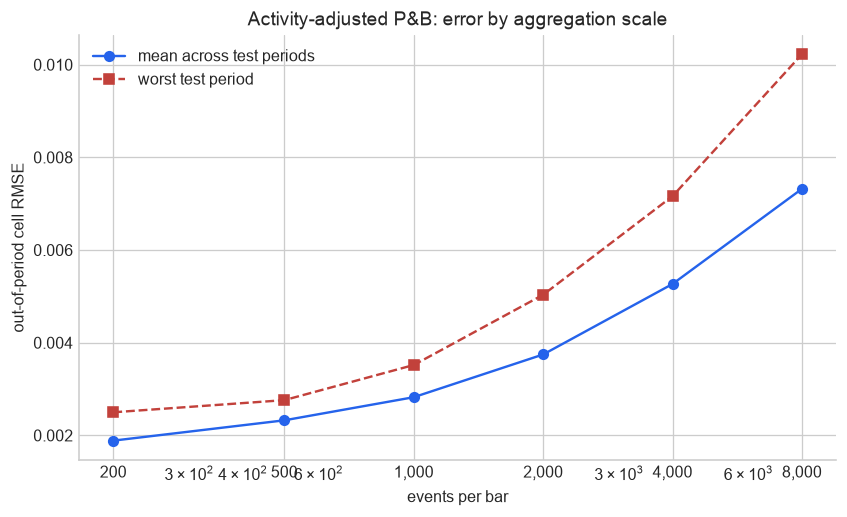

In [8]:
scale_view = evaluation.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('family') == FAMILY) &
    (pl.col('split') == 'test') &
    (pl.col('side') == 'all') &
    (pl.col('n_events') != 'all')
).with_columns(
    pl.col('n_events').cast(pl.Int64).alias('n_events_numeric')
)
scale_summary = scale_view.group_by('n_events_numeric').agg(
    pl.col('cell_rmse').mean().alias('mean_oos_rmse'),
    pl.col('cell_rmse').median().alias('median_oos_rmse'),
    pl.col('cell_rmse').max().alias('worst_oos_rmse'),
).sort('n_events_numeric')
display(scale_summary)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    scale_summary['n_events_numeric'], scale_summary['mean_oos_rmse'],
    'o-', color=MODEL_COLOURS[FAMILY], label='mean across test periods'
)
ax.plot(
    scale_summary['n_events_numeric'], scale_summary['worst_oos_rmse'],
    's--', color='#c2413b', label='worst test period'
)
ax.set_xscale('log')
ax.set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
ax.set_xlabel('events per bar')
ax.set_ylabel('out-of-period cell RMSE')
ax.set_title(f'{MODEL_LABELS[FAMILY]}: error by aggregation scale')
ax.legend()
plt.show()

## Parameter drift and the remaining activity residual

A cross-scale collapse can be valid locally while its parameters drift through calendar time. The residual/activity correlation is also important: a large value means the master curve has not fully removed activity state dependence.

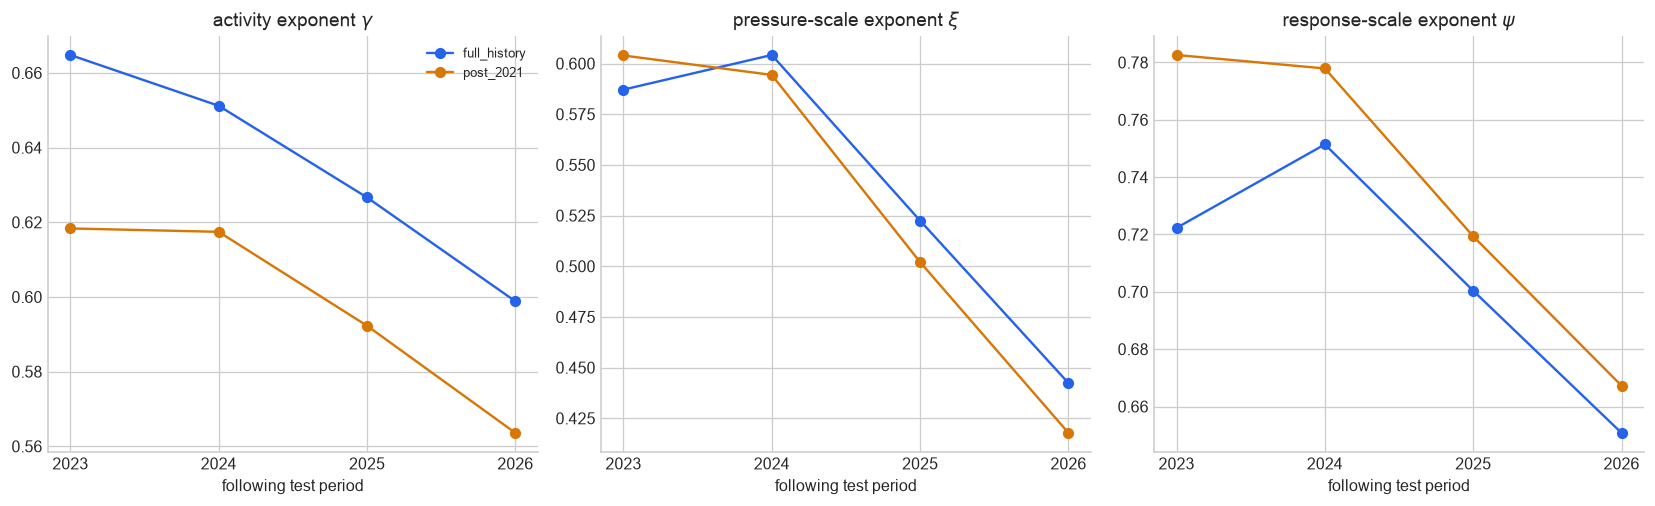

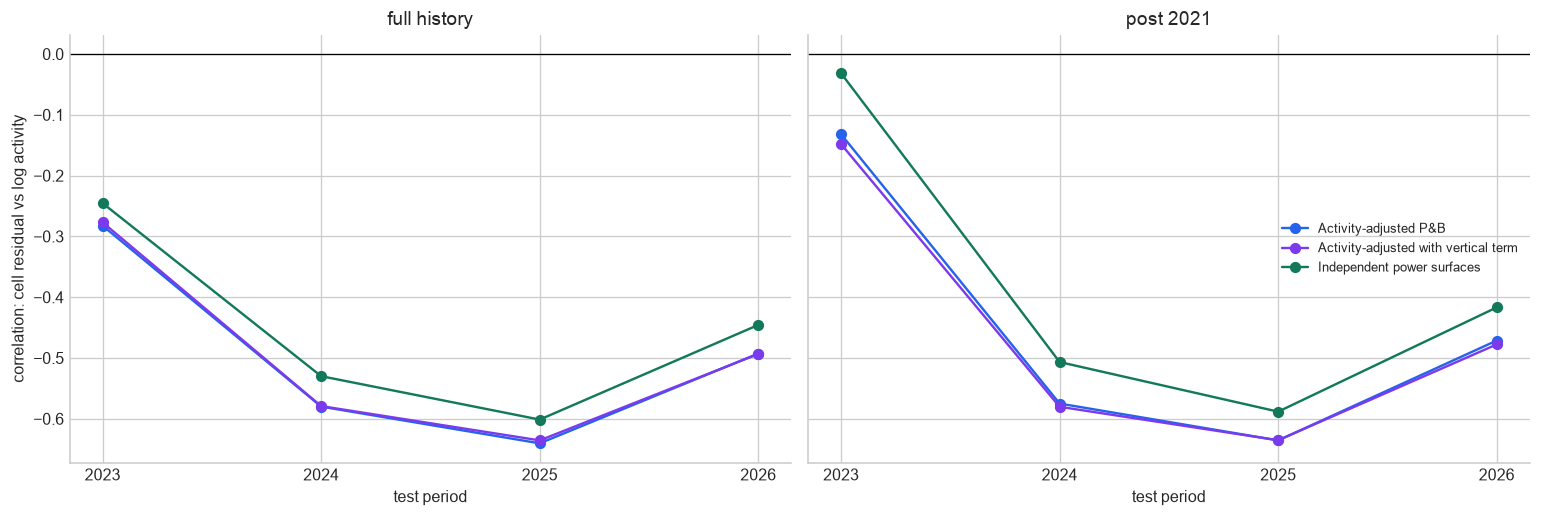

In [9]:
parameter_path = fits.filter(
    (pl.col('fold') != 'full_fit') &
    (pl.col('family') == 'pb_activity')
).with_columns(pl.col('fold').cast(pl.Int64).alias('fold_number'))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))
for sample, colour in [('full_history', '#2563eb'), ('post_2021', '#d97706')]:
    part = parameter_path.filter(pl.col('sample') == sample).sort('fold_number')
    axes[0].plot(part['fold_number'], part['activity_exponent_gamma'], 'o-',
                 color=colour, label=sample)
    axes[1].plot(part['fold_number'], part['q_exponent_xi'], 'o-', color=colour)
    axes[2].plot(part['fold_number'], part['r_exponent_psi'], 'o-', color=colour)
for ax, title in zip(
    axes,
    [r'activity exponent $\gamma$', r'pressure-scale exponent $\xi$',
     r'response-scale exponent $\psi$']
):
    ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
    ax.set_xlabel('following test period')
    ax.set_title(title)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

correlation = oos.filter(
    pl.col('family').is_in([
        'pb_activity', 'pb_activity_vertical', 'independent_power_surface'
    ])
)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
for ax, sample in zip(axes, ['full_history', 'post_2021']):
    for family in [
        'pb_activity', 'pb_activity_vertical', 'independent_power_surface'
    ]:
        part = correlation.filter(
            (pl.col('sample') == sample) & (pl.col('family') == family)
        ).sort('fold_number')
        ax.plot(
            part['fold_number'], part['residual_log_activity_correlation'],
            'o-', color=MODEL_COLOURS[family], label=MODEL_LABELS[family]
        )
    ax.axhline(0, color='black', lw=.8)
    ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
    ax.set_xlabel('test period')
    ax.set_title(sample.replace('_', ' '))
axes[0].set_ylabel('correlation: cell residual vs log activity')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Does a separate vertical activity exponent solve the problem?

The nested extension is

$$
\widehat y_{N,s}=\mathcal R_{N,s}\widetilde a^\delta
F\left(\frac{z a^\gamma}{\mathcal Q_N}\right),
$$

where $\widetilde a$ is divided by a training-fitted normal activity level for
each event scale. This centring prevents $\delta$ from mechanically duplicating
the event-count response exponent. At low pressure, however, $F(u)\approx u$ and
the total local activity exponent is approximately $\gamma+\delta$. Large opposing
changes in $\gamma$ and $\delta$ therefore reveal weak identification rather than
two securely estimated mechanisms.

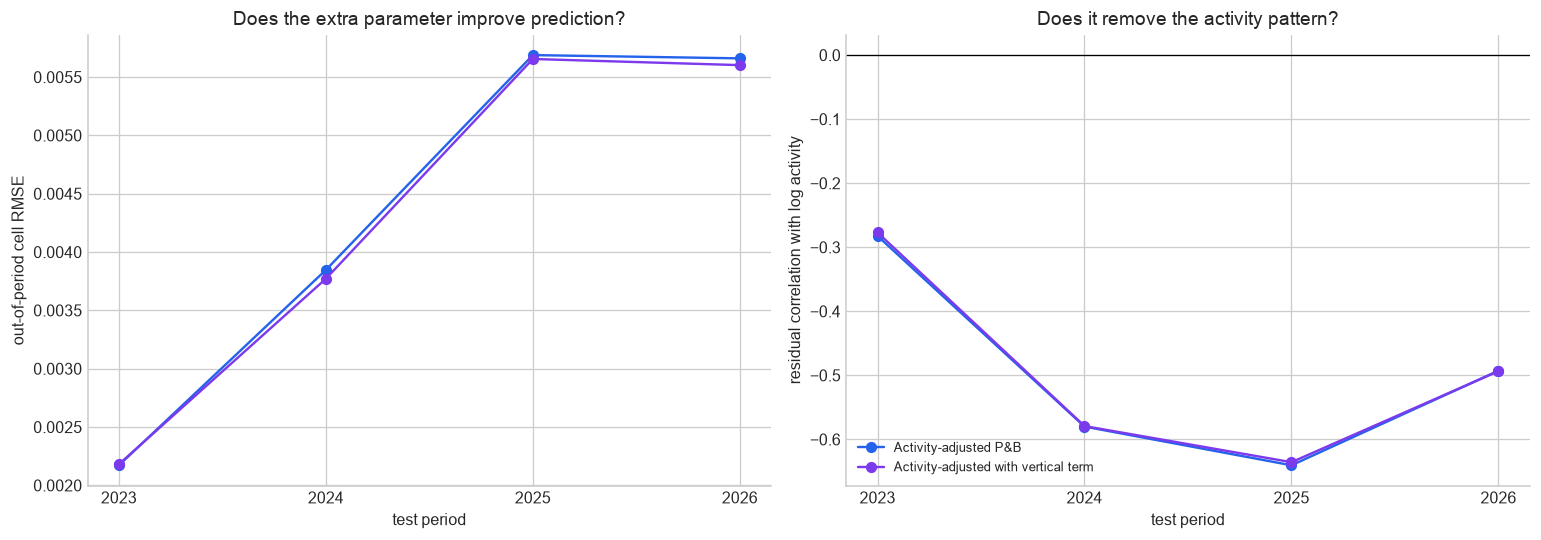

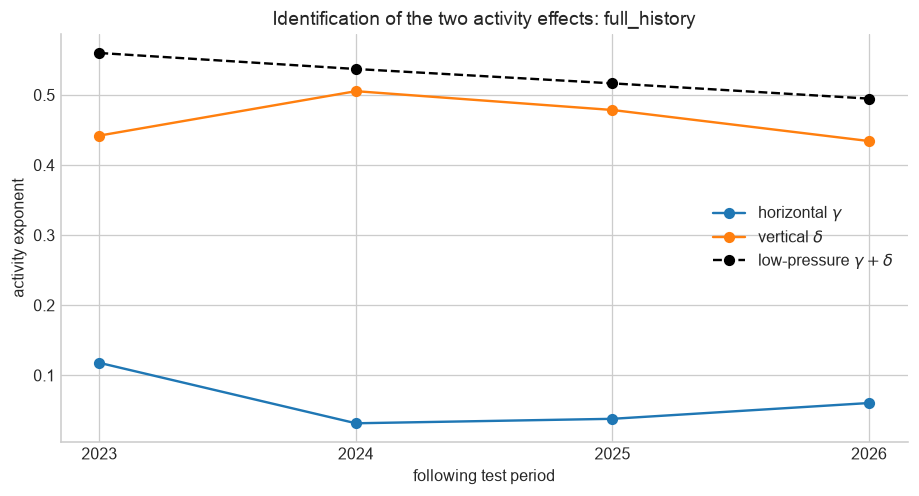

sample,family,mean_oos_rmse,mean_residual_activity_correlation
str,str,f64,f64
"""full_history""","""pb_activity_vertical""",0.004303,-0.496274
"""full_history""","""pb_activity""",0.004342,-0.49886
"""post_2021""","""pb_activity_vertical""",0.003968,-0.460344
"""post_2021""","""pb_activity""",0.004035,-0.453458


For `full_history`, the vertical term changes mean OOS RMSE by **0.91%**, while mean residual/log-activity correlation changes from **-0.499** to **-0.496**. A small RMSE gain without material decorrelation does not justify promoting the less identifiable model.

In [10]:
activity_extension = oos.filter(
    pl.col('family').is_in(['pb_activity', 'pb_activity_vertical'])
).with_columns(pl.col('fold').cast(pl.Int64).alias('fold_number'))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for family in ['pb_activity', 'pb_activity_vertical']:
    part = activity_extension.filter(
        (pl.col('sample') == SAMPLE) & (pl.col('family') == family)
    ).sort('fold_number')
    axes[0].plot(
        part['fold_number'], part['cell_rmse'], 'o-',
        color=MODEL_COLOURS[family], label=MODEL_LABELS[family]
    )
    axes[1].plot(
        part['fold_number'], part['residual_log_activity_correlation'], 'o-',
        color=MODEL_COLOURS[family], label=MODEL_LABELS[family]
    )
for ax in axes:
    ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
    ax.set_xlabel('test period')
axes[0].set_ylabel('out-of-period cell RMSE')
axes[0].set_title('Does the extra parameter improve prediction?')
axes[1].axhline(0, color='black', lw=.8)
axes[1].set_ylabel('residual correlation with log activity')
axes[1].set_title('Does it remove the activity pattern?')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

vertical_path = fits.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') != 'full_fit') &
    (pl.col('family') == 'pb_activity_vertical')
).with_columns(
    pl.col('fold').cast(pl.Int64).alias('fold_number'),
    (pl.col('activity_exponent_gamma') +
     pl.col('activity_vertical_exponent_delta')).alias('low_pressure_total')
).sort('fold_number')

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(vertical_path['fold_number'], vertical_path['activity_exponent_gamma'],
        'o-', label=r'horizontal $\gamma$')
ax.plot(vertical_path['fold_number'],
        vertical_path['activity_vertical_exponent_delta'],
        'o-', label=r'vertical $\delta$')
ax.plot(vertical_path['fold_number'], vertical_path['low_pressure_total'],
        'o--', color='black', label=r'low-pressure $\gamma+\delta$')
ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
ax.set_xlabel('following test period')
ax.set_ylabel('activity exponent')
ax.set_title(f'Identification of the two activity effects: {SAMPLE}')
ax.legend()
plt.show()

activity_extension_summary = (
    activity_extension.group_by('sample', 'family')
    .agg(
        pl.col('cell_rmse').mean().alias('mean_oos_rmse'),
        pl.col('residual_log_activity_correlation').mean()
        .alias('mean_residual_activity_correlation'),
    )
    .sort(['sample', 'mean_oos_rmse'])
)
display(activity_extension_summary)

base_row = activity_extension_summary.filter(
    (pl.col('sample') == SAMPLE) & (pl.col('family') == 'pb_activity')
).row(0, named=True)
vertical_row = activity_extension_summary.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('family') == 'pb_activity_vertical')
).row(0, named=True)
display(Markdown(
    f"For `{SAMPLE}`, the vertical term changes mean OOS RMSE by "
    f"**{100*(1-vertical_row['mean_oos_rmse']/base_row['mean_oos_rmse']):.2f}%**, "
    f"while mean residual/log-activity correlation changes from "
    f"**{base_row['mean_residual_activity_correlation']:+.3f}** to "
    f"**{vertical_row['mean_residual_activity_correlation']:+.3f}**. "
    "A small RMSE gain without material decorrelation does not justify promoting "
    "the less identifiable model."
))

## Does activity-dependent concavity capture the conditional curves?

The nested model lets

$$
\operatorname{logit}\beta(\widetilde a)
=b_0+b_1\log\widetilde a,
$$

so the high-pressure exponent becomes $1-\beta(\widetilde a)$. The following
plots use only the selected out-of-period fold. Low, middle and high activity
bands and pressure bins are defined from the corresponding training cells and
then frozen. Solid lines are observed test-cell means; dashed lines are the
model predictions on exactly the same cells.

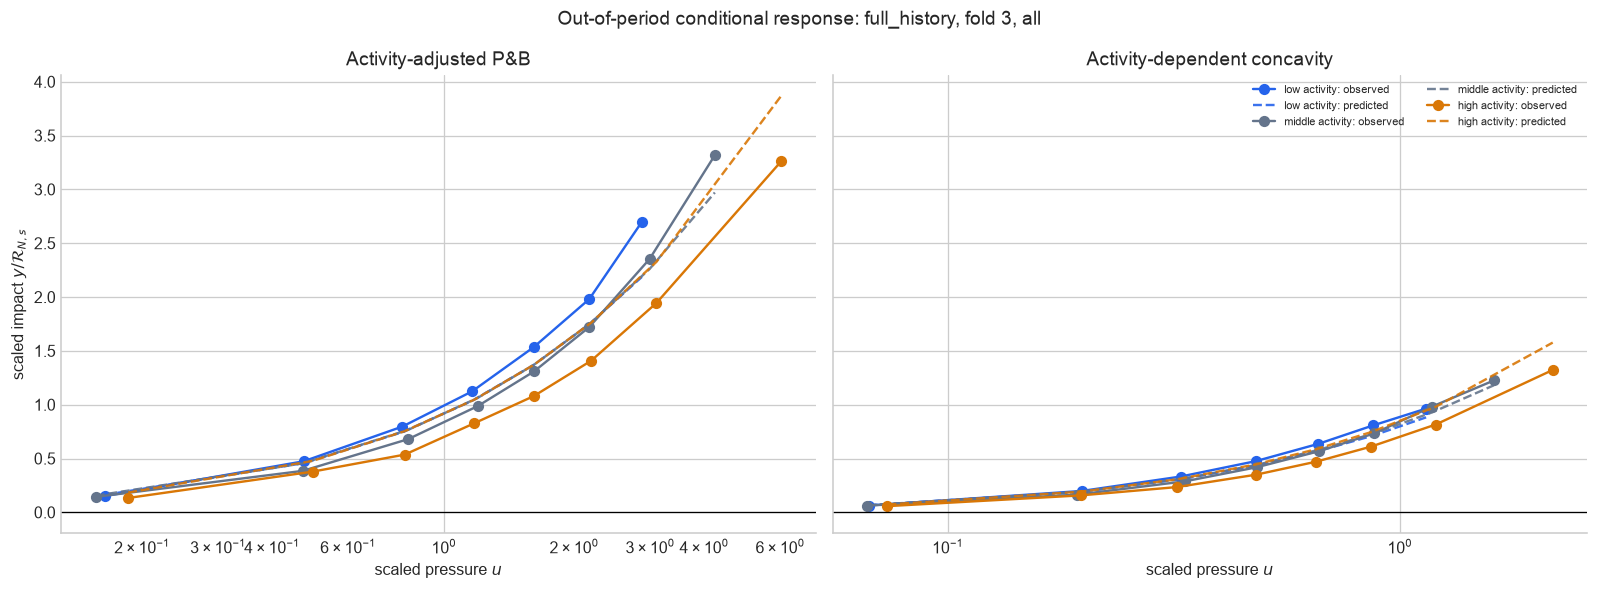

sample,family,mean_oos_rmse,mean_residual_activity_correlation
str,str,f64,f64
"""full_history""","""pb_activity_beta""",0.004329,-0.501239
"""full_history""","""pb_activity""",0.004342,-0.49886
"""post_2021""","""pb_activity_beta""",0.00397,-0.42508
"""post_2021""","""pb_activity""",0.004035,-0.453458


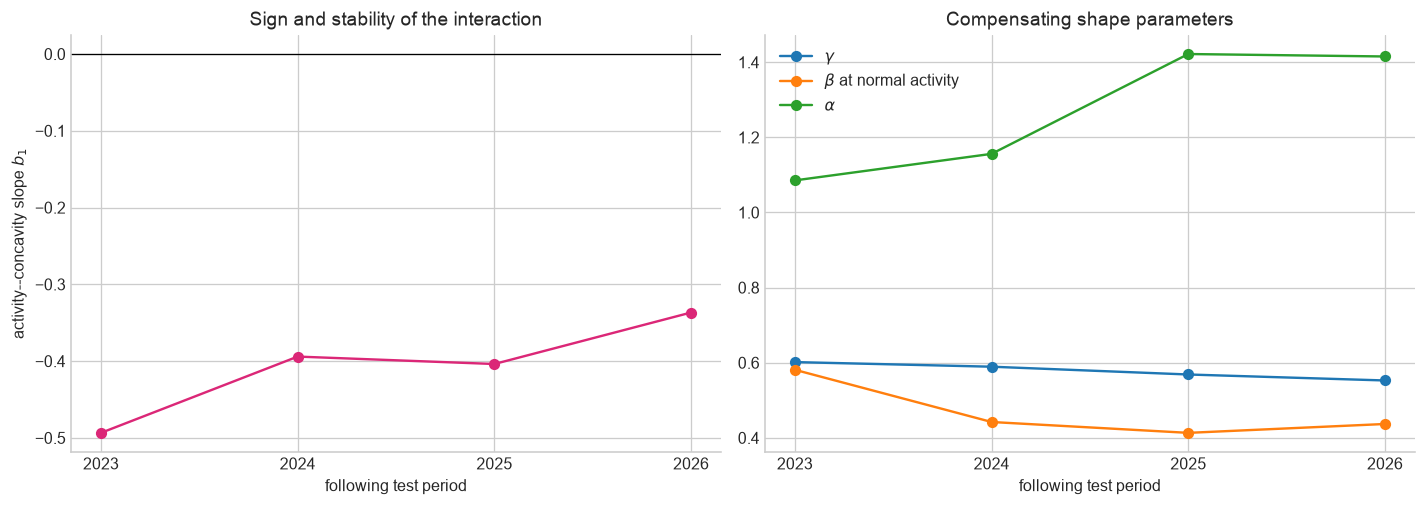

In [11]:
def conditional_curve_table(family):
    fit = fits.filter(
        (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
        (pl.col('fold') == DIAGNOSTIC_FOLD) &
        (pl.col('family') == family)
    ).row(0, named=True)
    training = scaling_cells.filter(
        (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
        (pl.col('fold') == DIAGNOSTIC_FOLD) &
        (pl.col('split') == 'train')
    )
    testing = scaling_cells.filter(
        (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
        (pl.col('fold') == DIAGNOSTIC_FOLD) &
        (pl.col('split') == 'test')
    )
    if DIAGNOSTIC_SIDE != 'all':
        training = training.filter(pl.col('side') == DIAGNOSTIC_SIDE)
        testing = testing.filter(pl.col('side') == DIAGNOSTIC_SIDE)

    def coordinates(frame):
        n = frame['n_events'].to_numpy().astype(float)
        ratio = n / fit['reference_events']
        side = np.where(frame['side'].to_numpy() == 'buy', 1, -1)
        z = frame['mean_relative_imbalance'].to_numpy()
        activity = frame['mean_relative_activity'].to_numpy()
        observed = frame['mean_normalised_impact'].to_numpy()
        q_scale = fit['q_reference'] * ratio ** fit['q_exponent_xi']
        r_reference = np.where(
            side > 0, fit['r_buy_reference'], fit['r_sell_reference']
        )
        r_scale = r_reference * ratio ** fit['r_exponent_psi']
        normal_activity = fit['activity_reference'] * (
            ratio ** fit['activity_scale_exponent_eta']
        )
        ell = np.log(activity / normal_activity)
        u = z * activity ** fit['activity_exponent_gamma'] / q_scale
        beta_fraction = fit['shape_beta'] / fit['central_exponent_p']
        beta_logit = np.log(beta_fraction / (1-beta_fraction))
        local_beta = fit['central_exponent_p'] / (
            1 + np.exp(-(
                beta_logit + fit['shape_beta_activity_slope'] * ell
            ))
        )
        shape = u ** fit['central_exponent_p'] / (
            1 + u ** fit['shape_alpha']
        ) ** (local_beta / fit['shape_alpha'])
        return ell, u, observed / r_scale, shape

    train_ell, train_u, _, _ = coordinates(training)
    test_ell, test_u, test_observed, test_prediction = coordinates(testing)
    activity_cuts = np.quantile(train_ell, [1/3, 2/3])
    pressure_cuts = np.quantile(
        np.log(train_u), np.linspace(0, 1, 9)[1:-1]
    )
    activity_band = np.digitize(test_ell, activity_cuts, right=True) + 1
    pressure_bin = np.digitize(
        np.log(test_u), pressure_cuts, right=True
    ) + 1
    frame = pl.DataFrame({
        'activity_band': activity_band,
        'pressure_bin': pressure_bin,
        'u': test_u,
        'observed': test_observed,
        'predicted': test_prediction,
    })
    return (
        frame.group_by('activity_band', 'pressure_bin')
        .agg(
            pl.col('u').mean(),
            pl.col('observed').mean(),
            pl.col('predicted').mean(),
            pl.len().alias('cells'),
        )
        .sort(['activity_band', 'pressure_bin'])
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
activity_colours = ['#2563eb', '#64748b', '#d97706']
activity_labels = ['low activity', 'middle activity', 'high activity']
for ax, family in zip(axes, ['pb_activity', 'pb_activity_beta']):
    curve_table = conditional_curve_table(family)
    for band, colour, label in zip(
        [1, 2, 3], activity_colours, activity_labels
    ):
        part = curve_table.filter(
            pl.col('activity_band') == band
        ).sort('u')
        ax.plot(part['u'], part['observed'], 'o-', color=colour,
                label=f'{label}: observed')
        ax.plot(part['u'], part['predicted'], '--', color=colour, alpha=.9,
                label=f'{label}: predicted')
    ax.set_xscale('log')
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel(r'scaled pressure $u$')
    ax.set_title(MODEL_LABELS[family])
axes[0].set_ylabel(r'scaled impact $y/\mathcal{R}_{N,s}$')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(
    f'Out-of-period conditional response: {DIAGNOSTIC_SAMPLE}, '
    f'fold {DIAGNOSTIC_FOLD}, {DIAGNOSTIC_SIDE}'
)
plt.tight_layout()
plt.show()

beta_oos = oos.filter(
    pl.col('family').is_in(['pb_activity', 'pb_activity_beta'])
)
beta_comparison = (
    beta_oos.group_by('sample', 'family')
    .agg(
        pl.col('cell_rmse').mean().alias('mean_oos_rmse'),
        pl.col('residual_log_activity_correlation').mean()
        .alias('mean_residual_activity_correlation'),
    )
    .sort(['sample', 'mean_oos_rmse'])
)
display(beta_comparison)

beta_path = fits.filter(
    (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
    (pl.col('family') == 'pb_activity_beta') &
    (pl.col('fold') != 'full_fit')
).with_columns(pl.col('fold').cast(pl.Int64).alias('fold_number')).sort('fold_number')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(beta_path['fold_number'], beta_path['shape_beta_activity_slope'],
             'o-', color=MODEL_COLOURS['pb_activity_beta'])
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_ylabel(r'activity--concavity slope $b_1$')
axes[0].set_title('Sign and stability of the interaction')
axes[1].plot(beta_path['fold_number'], beta_path['activity_exponent_gamma'],
             'o-', label=r'$\gamma$')
axes[1].plot(beta_path['fold_number'], beta_path['shape_beta'],
             'o-', label=r'$\beta$ at normal activity')
axes[1].plot(beta_path['fold_number'], beta_path['shape_alpha'],
             'o-', label=r'$\alpha$')
axes[1].set_title('Compensating shape parameters')
axes[1].legend()
for ax in axes:
    ax.set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
    ax.set_xlabel('following test period')
plt.tight_layout()
plt.show()

## Residual/activity diagnostic: out-of-period surface cells

These are the equal-weight test cells behind the residual/log-activity statistic.
Activity is expressed relative to its training-fitted normal level at each event
scale. Colour records scaled pressure, so a vertical colour gradient would warn
that an apparent activity relationship is actually a pressure relationship. Lines
are descriptive fits to test cells and are never used for prediction.

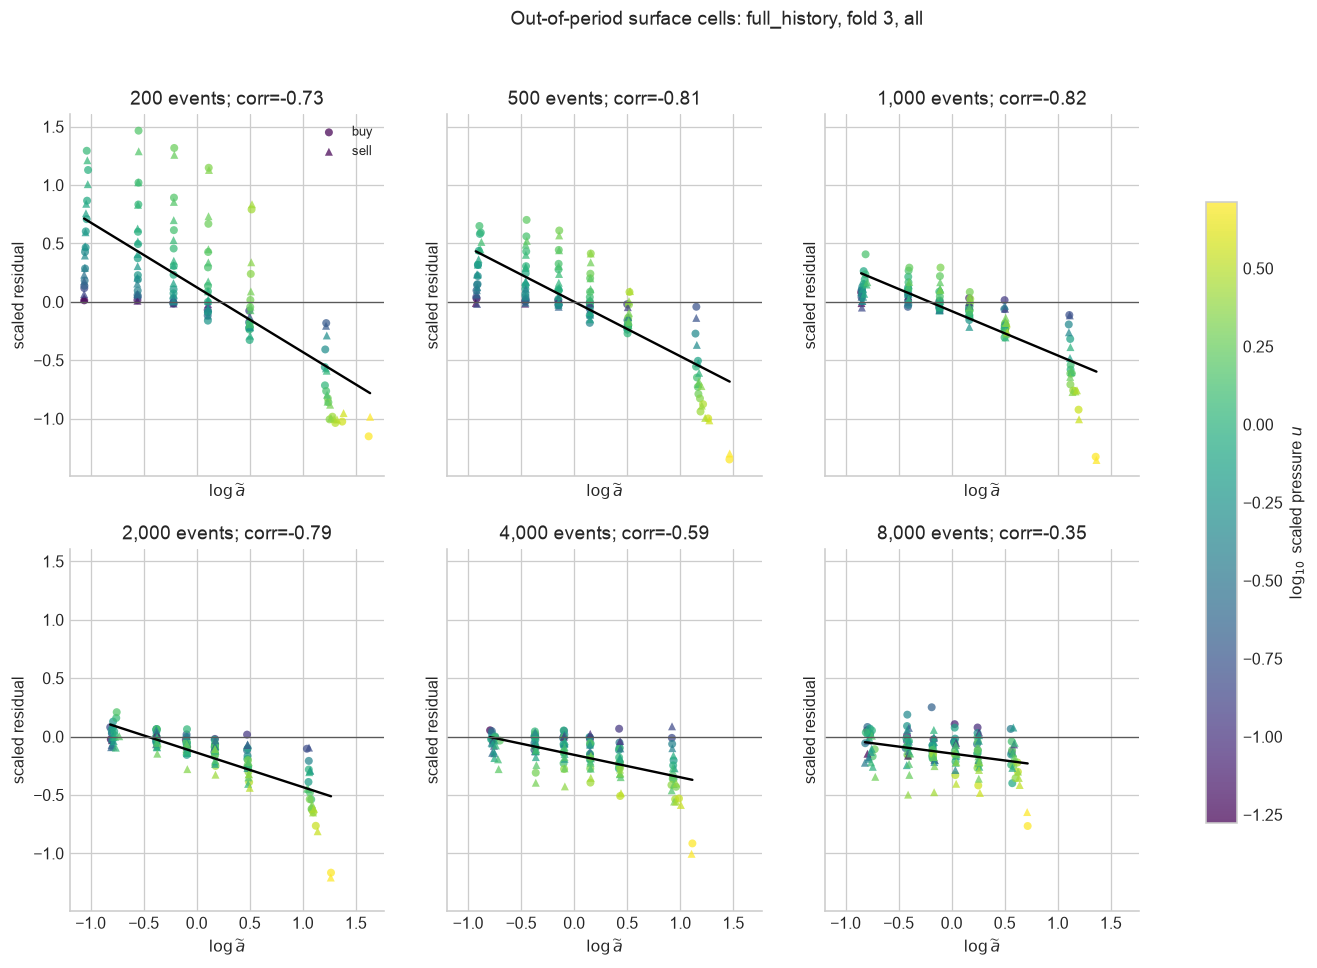

In [12]:
cell_view = cell_activity.filter(
    (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
    (pl.col('fold') == DIAGNOSTIC_FOLD)
)
if DIAGNOSTIC_SIDE != 'all':
    cell_view = cell_view.filter(pl.col('side') == DIAGNOSTIC_SIDE)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
last_scatter = None
for ax, n_events in zip(axes.flat, DISPLAY_SCALES):
    part = cell_view.filter(pl.col('n_events') == n_events)
    x = part['log_relative_activity'].to_numpy()
    y = part[DIAGNOSTIC_RESIDUAL].to_numpy()
    colour = np.log10(part['scaled_pressure'].to_numpy())
    for side_name, marker in [('buy', 'o'), ('sell', '^')]:
        chosen = part['side'].to_numpy() == side_name
        if chosen.any():
            last_scatter = ax.scatter(
                x[chosen], y[chosen], c=colour[chosen], cmap='viridis',
                marker=marker, s=25, alpha=.72, edgecolor='none',
                label=side_name
            )
    if len(x) > 2:
        slope_value, intercept_value = np.polyfit(x, y, 1)
        grid = np.linspace(x.min(), x.max(), 100)
        ax.plot(grid, intercept_value + slope_value * grid,
                color='black', lw=1.5)
        correlation_value = np.corrcoef(x, y)[0, 1]
    else:
        correlation_value = np.nan
    ax.axhline(0, color='0.35', lw=.8)
    ax.set_title(f'{n_events:,} events; corr={correlation_value:+.2f}')
    ax.set_xlabel(r'$\log\widetilde a$')
    ax.set_ylabel(DIAGNOSTIC_RESIDUAL.replace('_', ' '))
axes.flat[0].legend(fontsize=8)
if last_scatter is not None:
    fig.colorbar(
        last_scatter, ax=axes, shrink=.78,
        label=r'$\log_{10}$ scaled pressure $u$'
    )
fig.suptitle(
    f'Out-of-period surface cells: {DIAGNOSTIC_SAMPLE}, fold {DIAGNOSTIC_FOLD}, '
    f'{DIAGNOSTIC_SIDE}'
)
plt.show()

## Does the same pattern exist at bar level?

Each point is an out-of-period mean within an activity decile whose boundaries
were frozen from the corresponding training period. The shaded interval is two
naive standard errors and is descriptive only; serial dependence makes it too
optimistic for formal inference. Monthly diagnostics below provide the more useful
stability check.

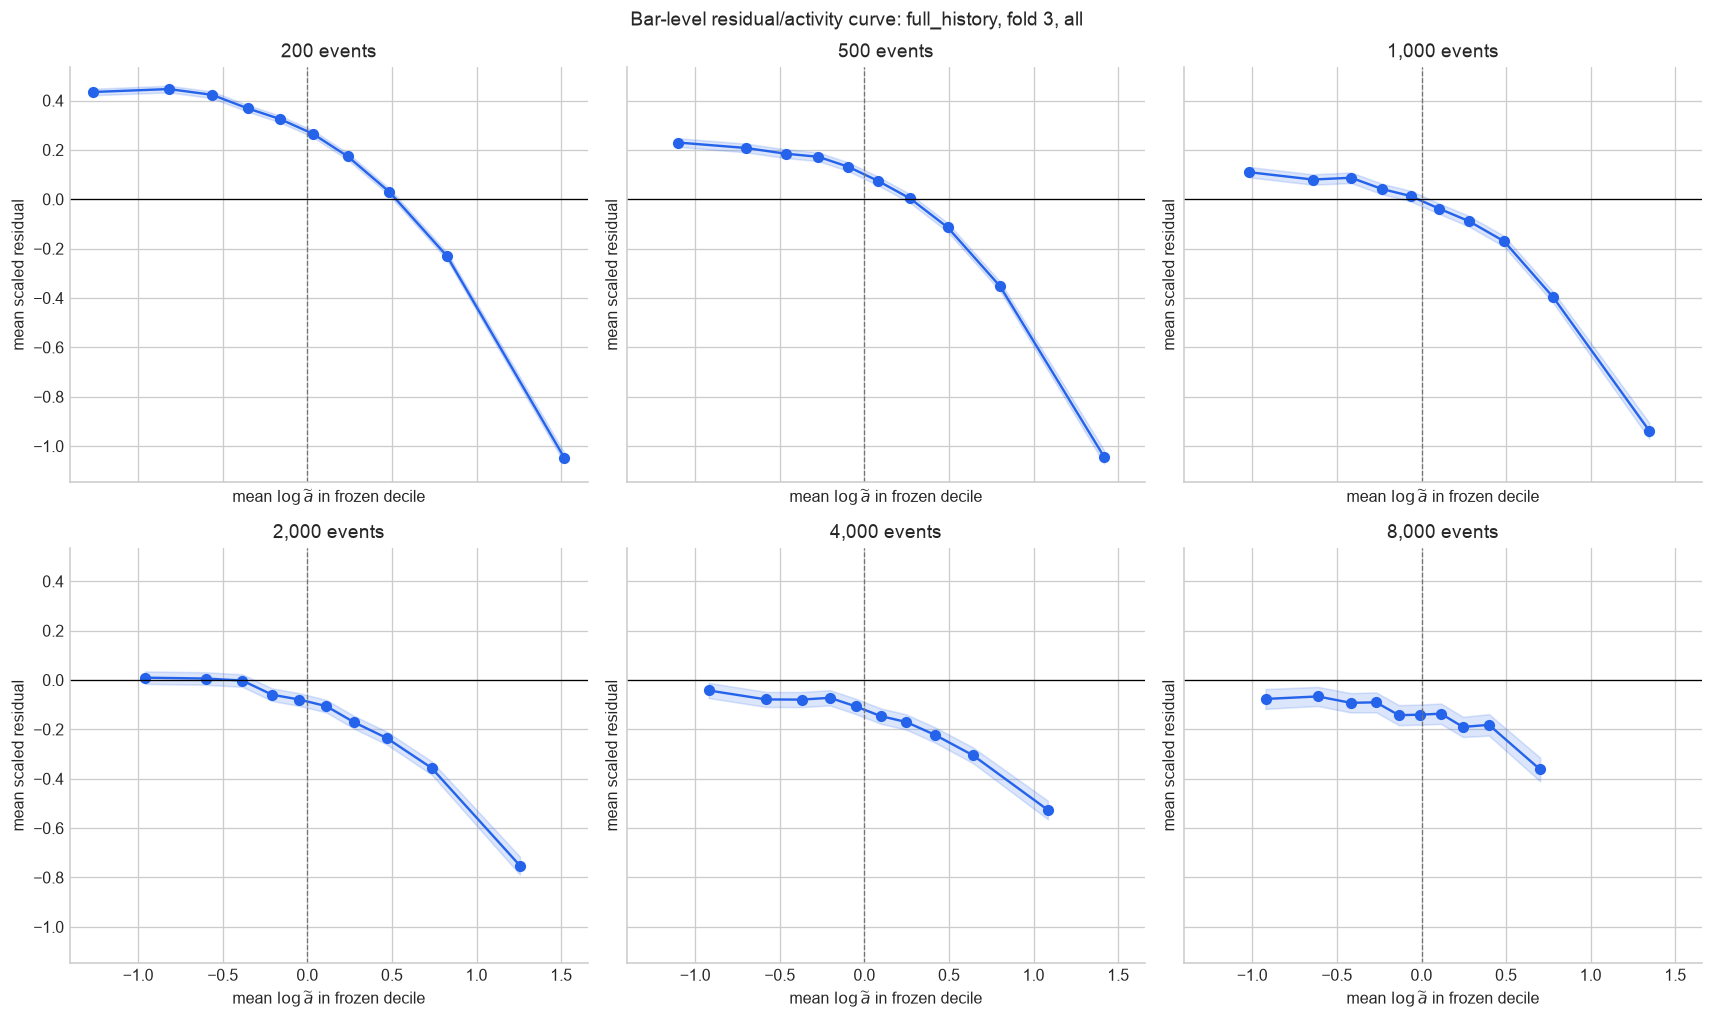

In [13]:
curve_view = bar_activity_curves.filter(
    (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
    (pl.col('fold') == DIAGNOSTIC_FOLD) &
    (pl.col('side') == DIAGNOSTIC_SIDE)
)
mean_column = f'mean_{DIAGNOSTIC_RESIDUAL}'
se_column = f'standard_error_{DIAGNOSTIC_RESIDUAL}'

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, n_events in zip(axes.flat, DISPLAY_SCALES):
    part = curve_view.filter(
        pl.col('n_events') == n_events
    ).sort('activity_bin')
    x = part['mean_log_relative_activity'].to_numpy()
    y = part[mean_column].to_numpy()
    se = part[se_column].to_numpy()
    ax.plot(x, y, 'o-', color='#2563eb')
    ax.fill_between(x, y - 2*se, y + 2*se, color='#2563eb', alpha=.16)
    ax.axhline(0, color='black', lw=.8)
    ax.axvline(0, color='0.45', lw=.8, ls='--')
    ax.set_title(f'{n_events:,} events')
    ax.set_xlabel(r'mean $\log\widetilde a$ in frozen decile')
    ax.set_ylabel(f'mean {DIAGNOSTIC_RESIDUAL.replace("_", " ")}')
fig.suptitle(
    f'Bar-level residual/activity curve: {DIAGNOSTIC_SAMPLE}, '
    f'fold {DIAGNOSTIC_FOLD}, {DIAGNOSTIC_SIDE}'
)
plt.tight_layout()
plt.show()

## Is activity merely proxying for scaled pressure?

The heatmap fixes pressure and activity simultaneously using training-frozen bins.
The lower panels compare the marginal monthly activity relationship with the same
relationship after removing pressure-bin means. If the controlled series remains
negative, activity contains residual structure beyond the fitted pressure coordinate.

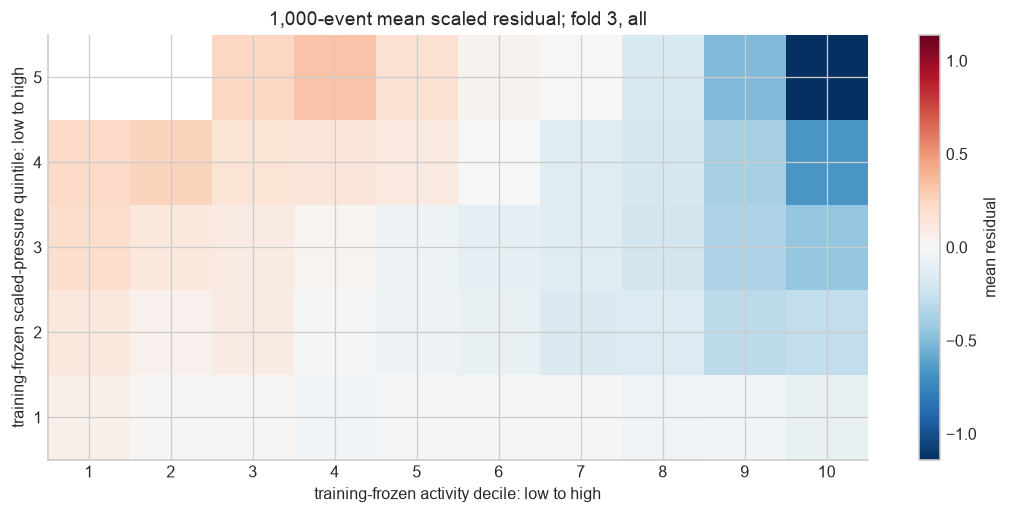

n_events,mean_marginal_correlation,mean_pressure_controlled_correlation,median_marginal_correlation,median_pressure_controlled_correlation,months
i64,f64,f64,f64,f64,u32
200,-0.090887,-0.109745,-0.117391,-0.129067,41
500,-0.103429,-0.100963,-0.128955,-0.113578,41
1000,-0.095535,-0.083393,-0.119987,-0.096034,41
2000,-0.076097,-0.05839,-0.098666,-0.069487,41
4000,-0.050318,-0.032165,-0.06942,-0.037731,41
8000,-0.02705,-0.010565,-0.038183,-0.012292,41


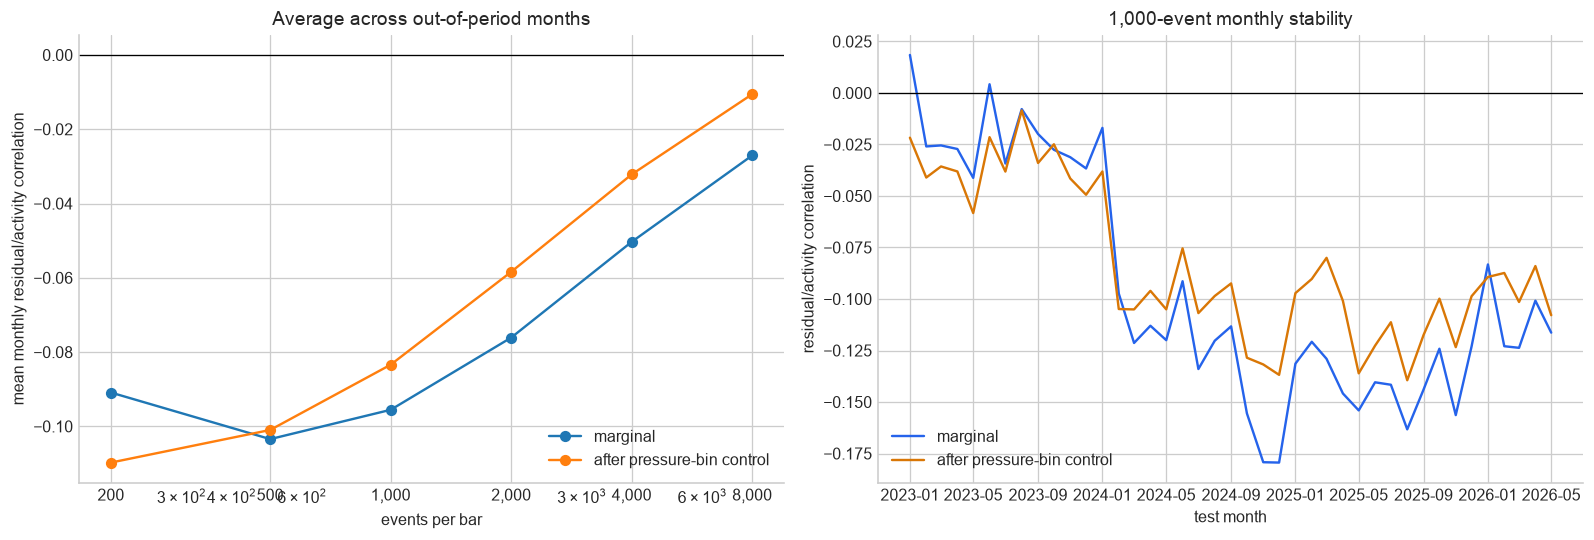

In [14]:
grid_view = bar_activity_grid.filter(
    (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
    (pl.col('fold') == DIAGNOSTIC_FOLD) &
    (pl.col('side') == DIAGNOSTIC_SIDE) &
    (pl.col('n_events') == DIAGNOSTIC_EVENT_SIZE)
)
pressure_bins = sorted(grid_view['pressure_bin'].unique().to_list())
activity_bins = sorted(grid_view['activity_bin'].unique().to_list())
matrix = np.full((len(pressure_bins), len(activity_bins)), np.nan)
for row in grid_view.iter_rows(named=True):
    i = pressure_bins.index(row['pressure_bin'])
    j = activity_bins.index(row['activity_bin'])
    matrix[i, j] = row[mean_column]

limit = np.nanmax(np.abs(matrix))
fig, ax = plt.subplots(figsize=(11.5, 4.8))
image = ax.imshow(
    matrix, origin='lower', aspect='auto', cmap='RdBu_r',
    vmin=-limit, vmax=limit
)
ax.set_xticks(range(len(activity_bins)), activity_bins)
ax.set_yticks(range(len(pressure_bins)), pressure_bins)
ax.set_xlabel('training-frozen activity decile: low to high')
ax.set_ylabel('training-frozen scaled-pressure quintile: low to high')
ax.set_title(
    f'{DIAGNOSTIC_EVENT_SIZE:,}-event mean {DIAGNOSTIC_RESIDUAL.replace("_", " ")}; '
    f'fold {DIAGNOSTIC_FOLD}, {DIAGNOSTIC_SIDE}'
)
fig.colorbar(image, ax=ax, label='mean residual')
plt.show()

monthly_view = monthly_activity.filter(
    (pl.col('sample') == DIAGNOSTIC_SAMPLE) &
    (pl.col('side') == DIAGNOSTIC_SIDE)
)
if DIAGNOSTIC_RESIDUAL == 'scaled_residual':
    marginal_column = 'scaled_activity_correlation'
    controlled_column = 'pressure_controlled_scaled_correlation'
else:
    marginal_column = 'raw_activity_correlation'
    controlled_column = 'pressure_controlled_raw_correlation'

relation_summary = (
    monthly_view.group_by('n_events')
    .agg(
        pl.col(marginal_column).mean().alias('mean_marginal_correlation'),
        pl.col(controlled_column).mean().alias('mean_pressure_controlled_correlation'),
        pl.col(marginal_column).median().alias('median_marginal_correlation'),
        pl.col(controlled_column).median()
        .alias('median_pressure_controlled_correlation'),
        pl.len().alias('months'),
    )
    .sort('n_events')
)
display(relation_summary)

selected_months = monthly_view.filter(
    pl.col('n_events') == DIAGNOSTIC_EVENT_SIZE
).sort('test_month')
dates = np.array([np.datetime64(value) for value in selected_months['test_month']])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(
    relation_summary['n_events'], relation_summary['mean_marginal_correlation'],
    'o-', label='marginal'
)
axes[0].plot(
    relation_summary['n_events'],
    relation_summary['mean_pressure_controlled_correlation'],
    'o-', label='after pressure-bin control'
)
axes[0].set_xscale('log')
axes[0].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_xlabel('events per bar')
axes[0].set_ylabel('mean monthly residual/activity correlation')
axes[0].set_title('Average across out-of-period months')
axes[0].legend()

axes[1].plot(
    dates, selected_months[marginal_column], color='#2563eb',
    label='marginal'
)
axes[1].plot(
    dates, selected_months[controlled_column], color='#d97706',
    label='after pressure-bin control'
)
axes[1].axhline(0, color='black', lw=.8)
axes[1].set_xlabel('test month')
axes[1].set_ylabel('residual/activity correlation')
axes[1].set_title(f'{DIAGNOSTIC_EVENT_SIZE:,}-event monthly stability')
axes[1].legend()
plt.tight_layout()
plt.show()

## Dynamic extension: can the previous bar explain the residual?

This is a deliberately nested extension of the preferred `pb_activity` surface.
It does **not** refit the P&B model after seeing the lag variables.

For each sample and chronological fold, the calibration sequence is:

1. fit the P&B surface on observations strictly before the fold's training
   cutoff, using the existing equal-weight surface-cell procedure;
2. freeze every P&B parameter: shape, activity exponent, event-count scaling,
   buy/sell response levels and normal activity scale;
3. evaluate that frozen model on the same training bars and calculate its
   residuals;
4. fit only the incremental lag coefficients to those training residuals, giving
   every training calendar month equal total weight;
5. freeze the lag coefficients and the training-only duration centre;
6. apply both layers unchanged throughout the following test period.

Thus, for fold 3, for example, the P&B calibration and the lag calibration both
end before 1 January 2025. Neither layer is updated while the 2025 test data are
evaluated. The precise dates and counts for the selected view are printed below.

Let $A_t$ be the side-aligned response predicted by the frozen P&B surface. The
previous-bar impulse, expressed in the direction of the current bar, is

$$
H_{t-1}=s_ts_{t-1}A_{t-1}.
$$

$H_{t-1}$ is positive when the two bars have the same pressure direction and
negative when their directions oppose. The simple dynamic model is

$$
y_t=A_t+c_{s_t}+\kappa H_{t-1}+\varepsilon_t.
$$

`bias_only` contains only the two nuisance means $c_{buy}$ and $c_{sell}$.
`lag_impact` adds $\kappa$. `lag_activity` then allows

$$
\kappa_t=\kappa_0+\kappa_a
\log\left(\frac{a_{t-1}}{a_N^*}\right),
$$

and `lag_activity_duration` adds a final interaction with current bar duration.
A negative $\kappa$ is counterreaction or decay; a positive value is continuation.

In [15]:
selected_ledger = calibration_ledger.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == OOS_FOLD) &
    (pl.col('n_events') == DIAGNOSTIC_EVENT_SIZE)
).select(
    'sample', 'fold', 'n_events', 'pb_family', 'pb_source_experiment',
    'train_start', 'pb_calibration_end', 'lag_calibration_end',
    'test_start', 'test_end', 'pb_parameters_frozen_before_lag_fit',
    'pb_fit_target', 'lag_fit_target', 'lag_weighting',
    'training_observations', 'test_observations',
    'duration_reference_seconds'
)
display(selected_ledger)

ledger_row = selected_ledger.row(0, named=True)
display(Markdown(
    f"**Selected calibration:** the P&B parameters were estimated using "
    f"`{ledger_row['train_start']}` through the last observation before "
    f"`{ledger_row['pb_calibration_end']}` and were then frozen. The lag layer "
    f"used residuals over that same past-only interval and was frozen at "
    f"`{ledger_row['lag_calibration_end']}`. Both layers were applied unchanged "
    f"from `{ledger_row['test_start']}` to `{ledger_row['test_end']}`."
))

sample,fold,n_events,pb_family,pb_source_experiment,train_start,pb_calibration_end,lag_calibration_end,test_start,test_end,pb_parameters_frozen_before_lag_fit,pb_fit_target,lag_fit_target,lag_weighting,training_observations,test_observations,duration_reference_seconds
str,str,i64,str,str,str,str,str,str,str,bool,str,str,str,i64,i64,f64
"""full_history""","""3""",1000,"""pb_activity""","""pb_surface_scaling_v1""","""2019-09-01""","""2025-01-01""","""2025-01-01""","""2025-01-01""","""2026-01-01""",true,"""equal_weight_training_cell_mea…","""bar_residual_after_frozen_pb""","""equal_total_weight_per_calenda…",1949951,335554,56.562


**Selected calibration:** the P&B parameters were estimated using `2019-09-01` through the last observation before `2025-01-01` and were then frozen. The lag layer used residuals over that same past-only interval and was frozen at `2025-01-01`. Both layers were applied unchanged from `2025-01-01` to `2026-01-01`.

### Out-of-period error and coefficient stability

n_events,model,mean_oos_monthly_rmse,mean_rmse_improvement_pct,worst_fold_improvement_pct,mean_pressure_controlled_activity_correlation,mean_residual_lag_correlation
i64,str,f64,f64,f64,f64,f64
200,"""bias_only""",0.011519,-0.042987,-0.226901,-0.114027,-0.164708
200,"""frozen_pb""",0.011514,0.0,0.0,-0.114019,-0.164738
200,"""lag_activity""",0.0114,1.009104,0.397104,-0.104394,0.012537
200,"""lag_activity_duration""",0.011421,0.824923,0.418504,-0.114945,-0.020303
200,"""lag_impact""",0.011388,1.123933,0.388731,-0.106862,0.061097
…,…,…,…,…,…,…
8000,"""bias_only""",0.055971,-0.223828,-0.317891,-0.01793,-0.185568
8000,"""frozen_pb""",0.05584,0.0,0.0,-0.017907,-0.185711
8000,"""lag_activity""",0.054973,1.548166,1.241199,-0.003189,-0.019503


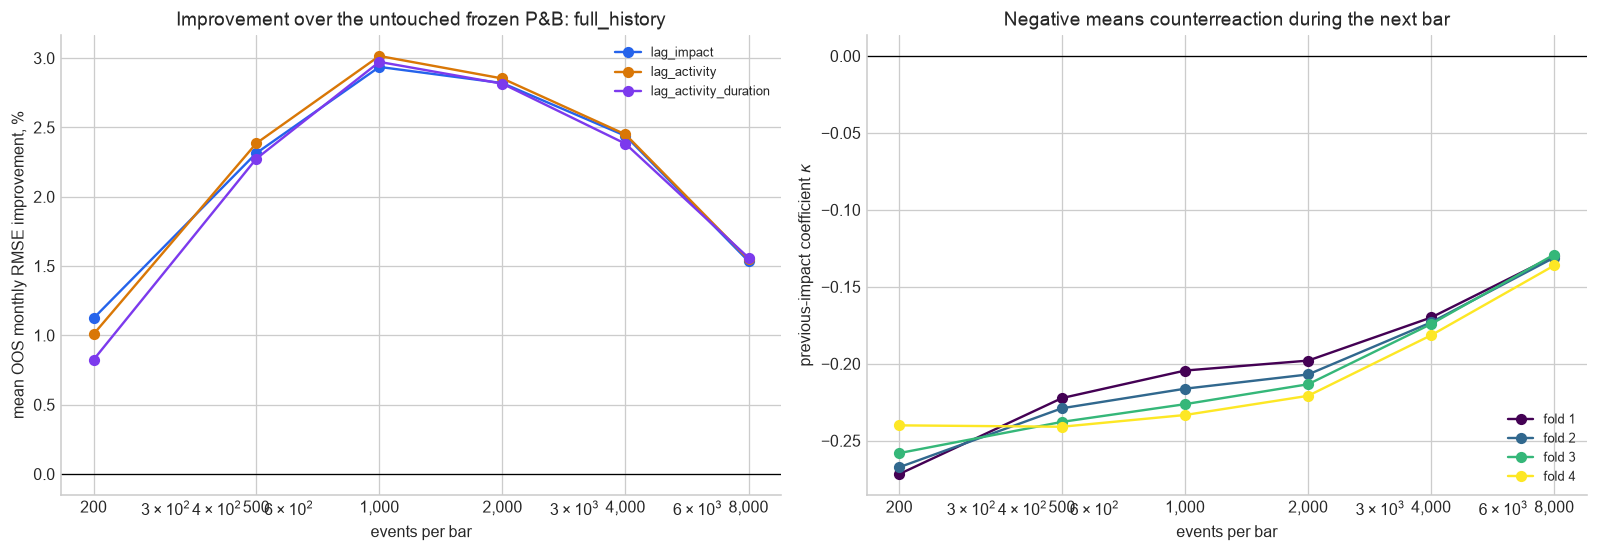

model,mean_condition_number,maximum_condition_number,minimum_lag_coefficient,maximum_lag_coefficient
str,f64,f64,f64,f64
"""bias_only""",1.0,1.0,0.0,0.0
"""lag_impact""",1.256672,1.399049,-0.271684,-0.129043
"""lag_activity""",228.800129,467.184836,-0.727647,0.089849
"""lag_activity_duration""",265.927502,539.16552,-0.216335,0.129833


In [16]:
lag_base = lag_evaluation.filter(
    pl.col('model') == 'frozen_pb'
).select(
    'sample', 'fold', 'n_events',
    pl.col('mean_monthly_rmse').alias('frozen_pb_rmse')
)
lag_comparison = lag_evaluation.join(
    lag_base, on=['sample', 'fold', 'n_events']
).with_columns(
    (100 * (1 - pl.col('mean_monthly_rmse') / pl.col('frozen_pb_rmse')))
    .alias('rmse_improvement_pct')
)

lag_summary = (
    lag_comparison.filter(pl.col('sample') == SAMPLE)
    .group_by('n_events', 'model')
    .agg(
        pl.col('mean_monthly_rmse').mean().alias('mean_oos_monthly_rmse'),
        pl.col('rmse_improvement_pct').mean().alias('mean_rmse_improvement_pct'),
        pl.col('rmse_improvement_pct').min().alias('worst_fold_improvement_pct'),
        pl.col('mean_monthly_pressure_controlled_activity_correlation').mean()
        .alias('mean_pressure_controlled_activity_correlation'),
        pl.col('mean_monthly_residual_lag_impulse_correlation').mean()
        .alias('mean_residual_lag_correlation'),
    )
    .sort(['n_events', 'model'])
)
display(lag_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.9))
lag_colours = {
    'lag_impact': '#2563eb',
    'lag_activity': '#d97706',
    'lag_activity_duration': '#7c3aed',
}
for model, colour in lag_colours.items():
    part = lag_summary.filter(pl.col('model') == model).sort('n_events')
    axes[0].plot(
        part['n_events'], part['mean_rmse_improvement_pct'], 'o-',
        color=colour, label=model
    )
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_xscale('log')
axes[0].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[0].set_xlabel('events per bar')
axes[0].set_ylabel('mean OOS monthly RMSE improvement, %')
axes[0].set_title(f'Improvement over the untouched frozen P&B: {SAMPLE}')
axes[0].legend(fontsize=8)

coefficient_path = lag_coefficients.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('model') == 'lag_impact')
).sort(['fold', 'n_events'])
for fold_value, colour in zip(['1', '2', '3', '4'], plt.cm.viridis(np.linspace(0, 1, 4))):
    part = coefficient_path.filter(pl.col('fold') == fold_value).sort('n_events')
    axes[1].plot(
        part['n_events'], part['lag_impulse'], 'o-', color=colour,
        label=f'fold {fold_value}'
    )
axes[1].axhline(0, color='black', lw=.8)
axes[1].set_xscale('log')
axes[1].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[1].set_xlabel('events per bar')
axes[1].set_ylabel(r'previous-impact coefficient $\kappa$')
axes[1].set_title('Negative means counterreaction during the next bar')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

identification = (
    lag_coefficients.filter(pl.col('sample') == SAMPLE)
    .group_by('model')
    .agg(
        pl.col('scaled_condition_number').mean().alias('mean_condition_number'),
        pl.col('scaled_condition_number').max().alias('maximum_condition_number'),
        pl.col('lag_impulse').min().alias('minimum_lag_coefficient'),
        pl.col('lag_impulse').max().alias('maximum_lag_coefficient'),
    )
    .sort('mean_condition_number')
)
display(identification)

### What does the lag relationship look like?

The x-axis below is the previous bar's frozen predicted impact aligned with the
current side. Negative values are therefore opposite-sign consecutive bars and
positive values are same-sign bars. Activity bands use cuts estimated from the
corresponding training period and then frozen. Faint solid lines show the original
P&B residual; dashed lines show the residual after the selected lag correction.

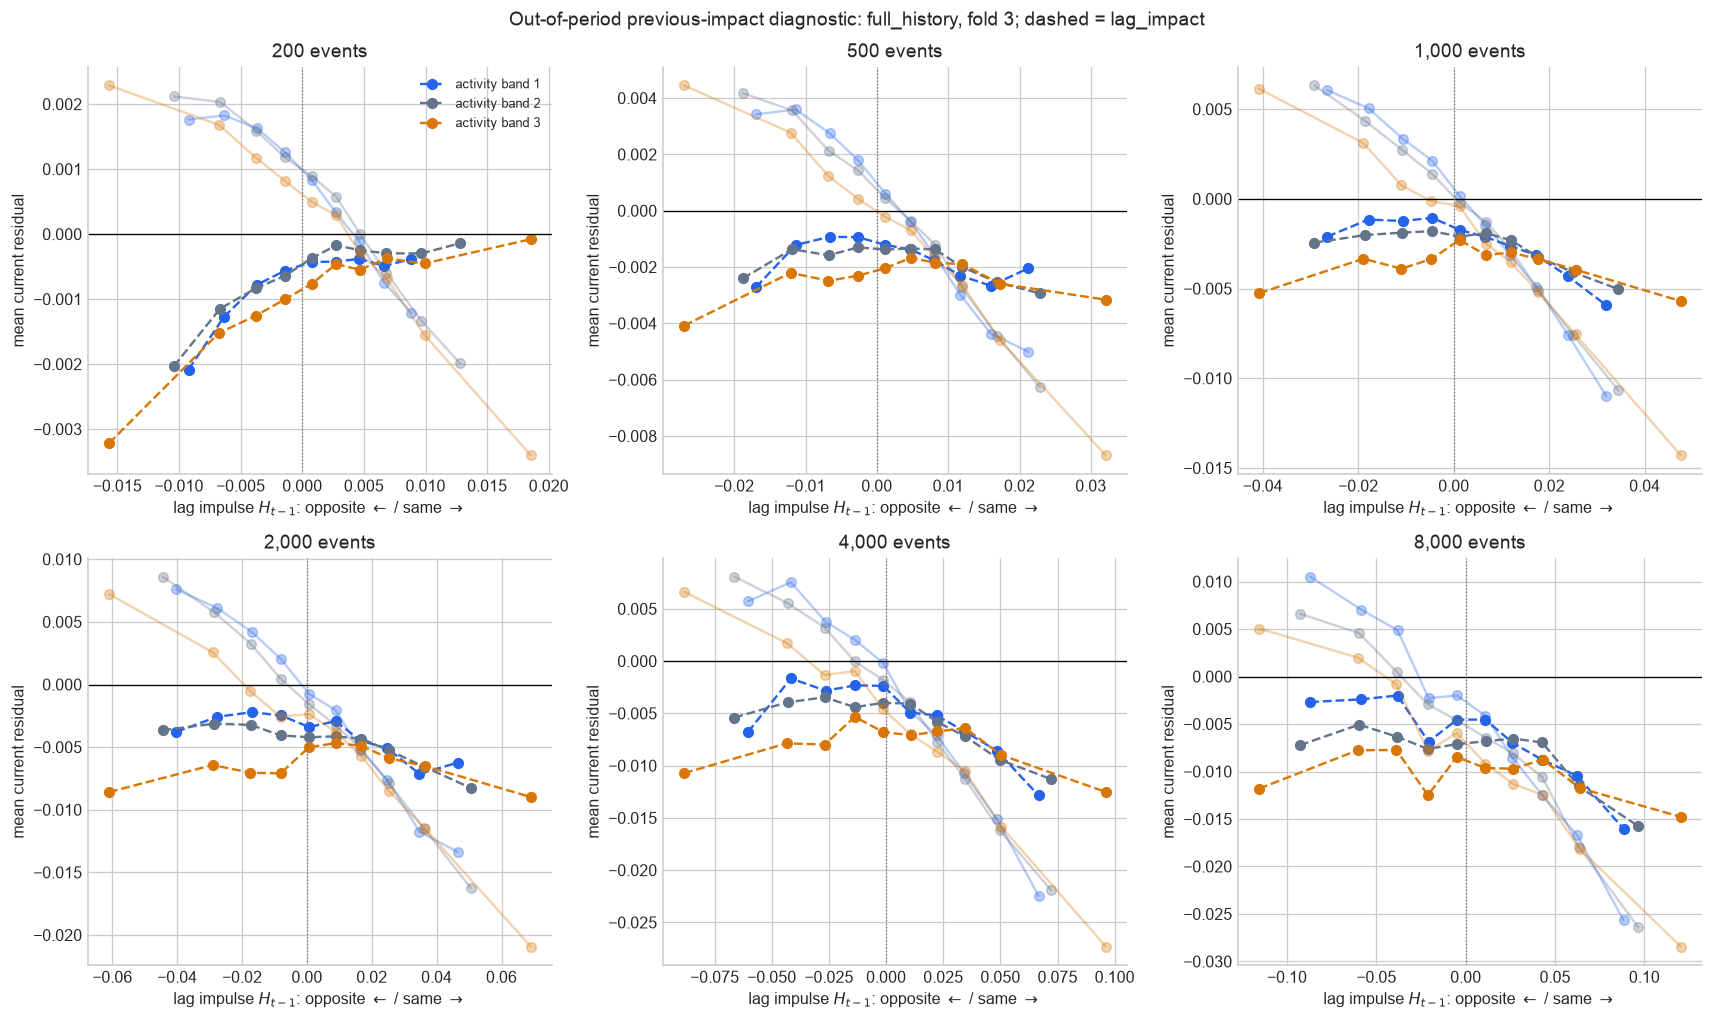

In [17]:
selected_lag_curves = lag_curves.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == OOS_FOLD)
)
activity_colours = ['#2563eb', '#64748b', '#d97706']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=False)
for ax, n_events in zip(axes.flat, DISPLAY_SCALES):
    scale_part = selected_lag_curves.filter(
        pl.col('n_events') == n_events
    )
    for band, colour in zip([1, 2, 3], activity_colours):
        part = scale_part.filter(
            pl.col('previous_activity_band') == band
        ).sort('mean_lag_impulse')
        ax.plot(
            part['mean_lag_impulse'], part['mean_residual_frozen_pb'],
            'o-', color=colour, alpha=.32
        )
        ax.plot(
            part['mean_lag_impulse'], part[f'mean_residual_{LAG_MODEL}'],
            'o--', color=colour, label=f'activity band {band}'
        )
    ax.axhline(0, color='black', lw=.8)
    ax.axvline(0, color='0.45', lw=.8, ls=':')
    ax.set_title(f'{n_events:,} events')
    ax.set_xlabel(r'lag impulse $H_{t-1}$: opposite $\leftarrow$ / same $\rightarrow$')
    ax.set_ylabel('mean current residual')
axes.flat[0].legend(fontsize=8)
fig.suptitle(
    f'Out-of-period previous-impact diagnostic: {SAMPLE}, fold {OOS_FOLD}; '
    f'dashed = {LAG_MODEL}'
)
plt.tight_layout()
plt.show()

### Does the lag layer also remove the activity residual?

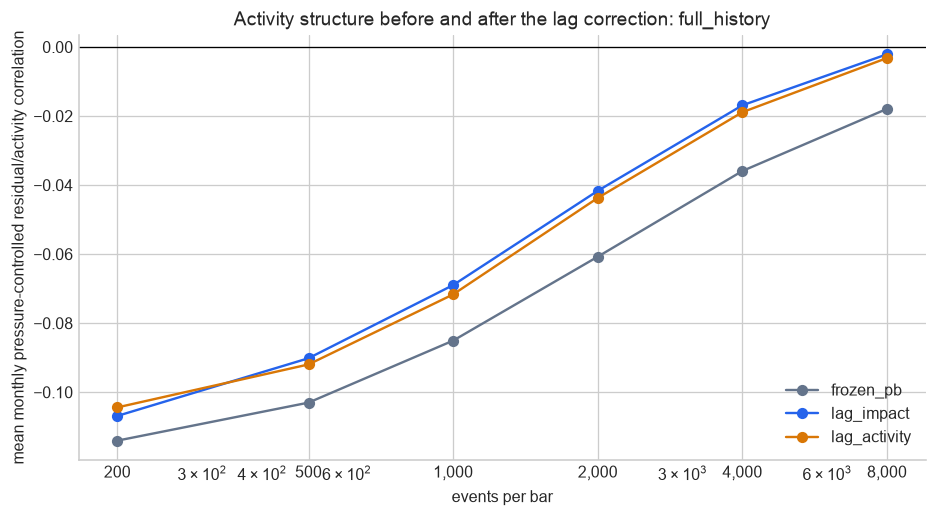

model,bias_buy,bias_sell,lag_impulse,lag_impulse_x_previous_activity,lag_impulse_x_duration,scaled_condition_number,training_observations,training_months
str,f64,f64,f64,f64,f64,f64,i64,i64
"""bias_only""",0.001395,0.001376,0.0,0.0,0.0,1.0,1949951,64
"""lag_activity""",0.00232,0.002226,0.08561,0.051696,0.0,175.740417,1949951,64
"""lag_activity_duration""",0.002317,0.002223,0.087593,0.05199,-0.001066,183.776843,1949951,64
"""lag_impact""",0.002203,0.002125,-0.226268,0.0,0.0,1.303169,1949951,64


In [18]:
activity_after_lag = (
    lag_evaluation.filter(
        (pl.col('sample') == SAMPLE) &
        pl.col('model').is_in(['frozen_pb', 'lag_impact', 'lag_activity'])
    )
    .group_by('n_events', 'model')
    .agg(
        pl.col('mean_monthly_pressure_controlled_activity_correlation').mean()
        .alias('mean_correlation')
    )
    .sort(['model', 'n_events'])
)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for model, colour in [
    ('frozen_pb', '#64748b'),
    ('lag_impact', '#2563eb'),
    ('lag_activity', '#d97706'),
]:
    part = activity_after_lag.filter(pl.col('model') == model).sort('n_events')
    ax.plot(part['n_events'], part['mean_correlation'], 'o-', color=colour, label=model)
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('log')
ax.set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
ax.set_xlabel('events per bar')
ax.set_ylabel('mean monthly pressure-controlled residual/activity correlation')
ax.set_title(f'Activity structure before and after the lag correction: {SAMPLE}')
ax.legend()
plt.show()

selected_coefficients = lag_coefficients.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == OOS_FOLD) &
    (pl.col('n_events') == DIAGNOSTIC_EVENT_SIZE)
).select(
    'model', 'bias_buy', 'bias_sell', 'lag_impulse',
    'lag_impulse_x_previous_activity', 'lag_impulse_x_duration',
    'scaled_condition_number', 'training_observations', 'training_months'
).sort('model')
display(selected_coefficients)

## Quantitative reading of this run

In [19]:
def mean_oos(sample, family):
    return summary.filter(
        (pl.col('sample') == sample) & (pl.col('family') == family)
    )['mean_oos_rmse'][0]

classic = mean_oos(SAMPLE, 'pb_classic')
adjusted = mean_oos(SAMPLE, 'pb_activity')
vertical = mean_oos(SAMPLE, 'pb_activity_vertical')
activity_beta = mean_oos(SAMPLE, 'pb_activity_beta')
generalised = mean_oos(SAMPLE, 'pb_activity_generalised')
benchmark = mean_oos(SAMPLE, 'independent_power_surface')
full_adjusted = mean_oos('full_history', 'pb_activity')
post_adjusted = mean_oos('post_2021', 'pb_activity')

display(Markdown(
    f"- For `{SAMPLE}`, activity adjustment reduces mean OOS RMSE by "
    f"**{100*(1-adjusted/classic):.1f}%** relative to the original P&B coordinate.\n"
    f"- Freeing the central exponent changes mean OOS RMSE by "
    f"**{100*(1-generalised/adjusted):.2f}%**; it is not earning its extra freedom in this run.\n"
    f"- Adding a vertical activity exponent changes mean OOS RMSE by "
    f"**{100*(1-vertical/adjusted):.2f}%** relative to the activity-adjusted model.\n"
    f"- Making concavity activity-dependent changes mean OOS RMSE by "
    f"**{100*(1-activity_beta/adjusted):.2f}%** relative to the activity-adjusted model.\n"
    f"- The scale-free activity model is only **{100*(adjusted/benchmark-1):.1f}%** "
    f"worse than independent surfaces fitted separately at every scale and side.\n"
    f"- Starting training in 2021 changes mean OOS RMSE from "
    f"**{full_adjusted:.6f}** to **{post_adjusted:.6f}**, an improvement of "
    f"**{100*(1-post_adjusted/full_adjusted):.1f}%** over the common 2023–2026 tests."
))

- For `full_history`, activity adjustment reduces mean OOS RMSE by **28.1%** relative to the original P&B coordinate.
- Freeing the central exponent changes mean OOS RMSE by **-0.01%**; it is not earning its extra freedom in this run.
- Adding a vertical activity exponent changes mean OOS RMSE by **0.91%** relative to the activity-adjusted model.
- Making concavity activity-dependent changes mean OOS RMSE by **0.31%** relative to the activity-adjusted model.
- The scale-free activity model is only **1.0%** worse than independent surfaces fitted separately at every scale and side.
- Starting training in 2021 changes mean OOS RMSE from **0.004342** to **0.004035**, an improvement of **7.1%** over the common 2023–2026 tests.

## Rolling calibration: is gamma stable?

These fits use only the preceding 6 or 12 calendar months and are frozen for the following month. They are the calibrations used for the predictive residual test below.

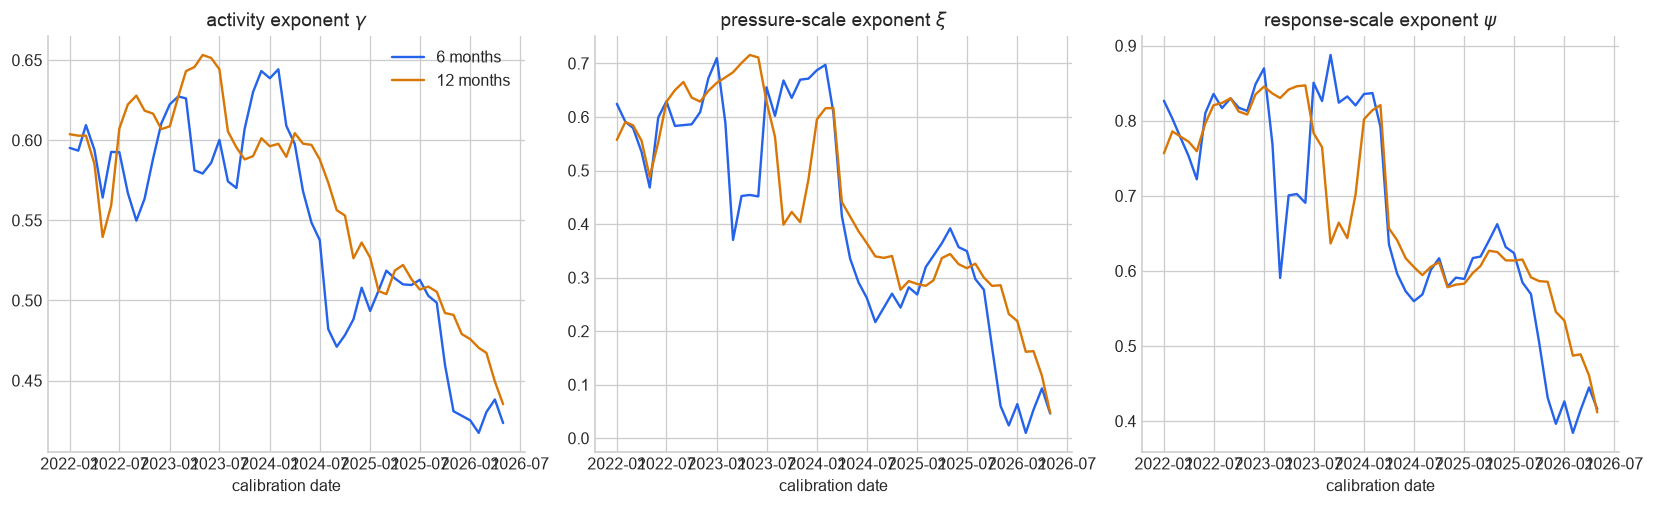

training_window_months,mean_gamma,gamma_std,gamma_min,gamma_max,mean_xi,mean_psi
i64,f64,f64,f64,f64,f64,f64
6,0.544542,0.067074,0.417355,0.644297,0.415663,0.674774
12,0.564839,0.058257,0.435282,0.65323,0.444959,0.685389


In [20]:
rolling_dates = np.array(
    [np.datetime64(value) for value in rolling_fits['calibration_date'].to_list()]
)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))
for window, colour in [(6, '#2563eb'), (12, '#d97706')]:
    part = rolling_fits.filter(
        pl.col('training_window_months') == window
    ).sort('calibration_date')
    dates = np.array([np.datetime64(value) for value in part['calibration_date']])
    axes[0].plot(dates, part['activity_exponent_gamma'], color=colour,
                 label=f'{window} months')
    axes[1].plot(dates, part['q_exponent_xi'], color=colour)
    axes[2].plot(dates, part['r_exponent_psi'], color=colour)
for ax, title in zip(
    axes,
    [r'activity exponent $\gamma$', r'pressure-scale exponent $\xi$',
     r'response-scale exponent $\psi$']
):
    ax.set_title(title)
    ax.set_xlabel('calibration date')
axes[0].legend()
plt.tight_layout()
plt.show()

display(
    rolling_fits.group_by('training_window_months').agg(
        pl.col('activity_exponent_gamma').mean().alias('mean_gamma'),
        pl.col('activity_exponent_gamma').std().alias('gamma_std'),
        pl.col('activity_exponent_gamma').min().alias('gamma_min'),
        pl.col('activity_exponent_gamma').max().alias('gamma_max'),
        pl.col('q_exponent_xi').mean().alias('mean_xi'),
        pl.col('r_exponent_psi').mean().alias('mean_psi'),
    ).sort('training_window_months')
)

## Residual correlation with future returns

For each completed bar, define

$$
\varepsilon_t=\frac{y_t-\widehat y_t}{\mathcal R_{N,s}},
\qquad
g_{t,h}=\operatorname{sign}(Q_t)r_{t,t+h}.
$$

For cross-scale comparison, `conditional_z` robustly centres and scales
$\varepsilon_t$ using only the preceding three months, separately for buy and sell
bars and within training-frozen scaled-pressure quintiles. `scaled` retains the
direct model-error units. The 30-second observation is the first post-close
horizon; the event bar itself is never used as a future target.

A negative information coefficient means that unusually high impact tends to reverse. A positive coefficient means continuation. The Spearman statistic tests monotonic ordering and is less sensitive to a few extreme returns than Pearson correlation.

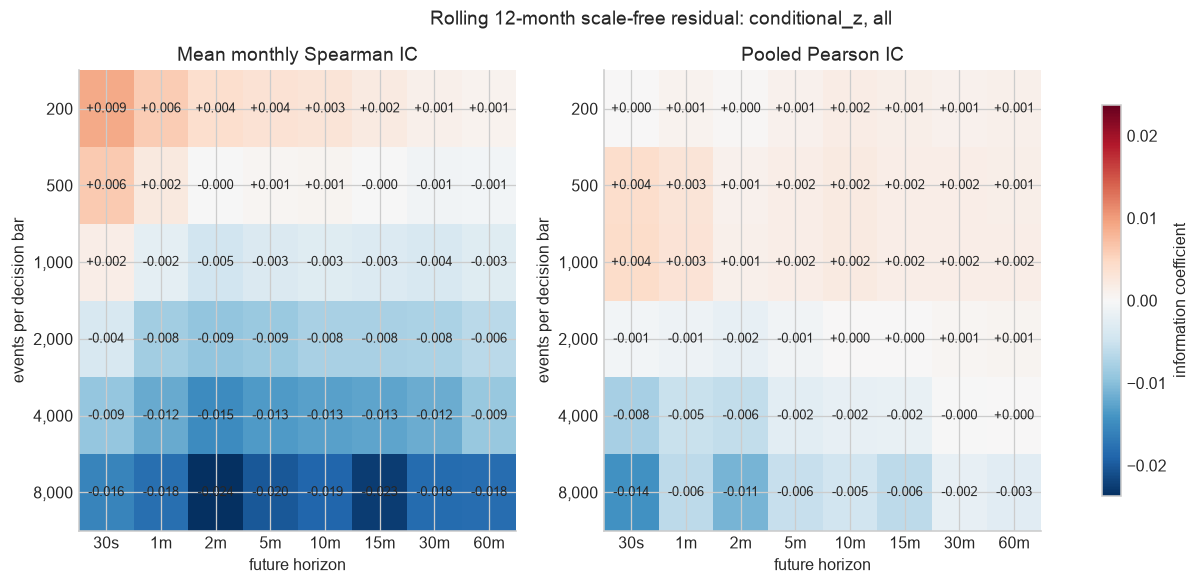

n_events,observations,pooled_pearson_ic,mean_monthly_spearman_ic,median_monthly_spearman_ic,monthly_spearman_t_stat,negative_spearman_month_fraction,median_elapsed_seconds,p90_elapsed_seconds
i64,i64,f64,f64,f64,f64,f64,f64,f64
200,8639295,0.001368,0.002174,0.002488,4.257769,0.245283,906.958,924.5837
500,3455720,0.001666,-0.000139,0.000035,-0.208332,0.490566,906.951,924.501
1000,1727860,0.00151,-0.003217,-0.002567,-3.901278,0.698113,906.964,924.46
2000,863888,0.000071,-0.007741,-0.007727,-6.169057,0.849057,906.938,924.336
4000,425635,-0.001802,-0.012585,-0.010451,-7.495732,0.886792,906.7935,923.9932
8000,171938,-0.006162,-0.022522,-0.019229,-7.033158,0.886792,906.234,921.5246


In [21]:
ic_view = residual_ic_summary.filter(
    (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
    (pl.col('side') == IC_SIDE) &
    (pl.col('residual_variant') == RESIDUAL_VARIANT)
).sort(['n_events', 'horizon_seconds'])

event_sizes = sorted(ic_view['n_events'].unique().to_list())
horizons = sorted(ic_view['horizon_seconds'].unique().to_list())
spearman_matrix = np.full((len(event_sizes), len(horizons)), np.nan)
pearson_matrix = np.full_like(spearman_matrix, np.nan)
for row in ic_view.iter_rows(named=True):
    i = event_sizes.index(row['n_events'])
    j = horizons.index(row['horizon_seconds'])
    spearman_matrix[i, j] = row['mean_monthly_spearman_ic']
    pearson_matrix[i, j] = row['pooled_pearson_ic']

limit = max(np.nanmax(np.abs(spearman_matrix)), np.nanmax(np.abs(pearson_matrix)))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
for ax, matrix, title in [
    (axes[0], spearman_matrix, 'Mean monthly Spearman IC'),
    (axes[1], pearson_matrix, 'Pooled Pearson IC'),
]:
    image = ax.imshow(matrix, cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(range(len(horizons)), [horizon_label(h) for h in horizons])
    ax.set_yticks(range(len(event_sizes)), [f'{n:,}' for n in event_sizes])
    ax.set_xlabel('future horizon')
    ax.set_ylabel('events per decision bar')
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i,j]:+.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes, shrink=.85, label='information coefficient')
fig.suptitle(
    f'Rolling {IC_TRAINING_WINDOW}-month scale-free residual: '
    f'{RESIDUAL_VARIANT}, {IC_SIDE}'
)
plt.show()

display(
    ic_view.filter(pl.col('horizon_seconds') == IC_HORIZON_SECONDS)
    .select(
        'n_events', 'observations', 'pooled_pearson_ic',
        'mean_monthly_spearman_ic', 'median_monthly_spearman_ic',
        'monthly_spearman_t_stat', 'negative_spearman_month_fraction',
        'median_elapsed_seconds', 'p90_elapsed_seconds'
    )
)

## What do the residual quintiles actually do?

All returns below are aligned with the direction of the current bar. Negative values therefore indicate subsequent reversal. The median is important because raw mean returns are affected by rare large moves.

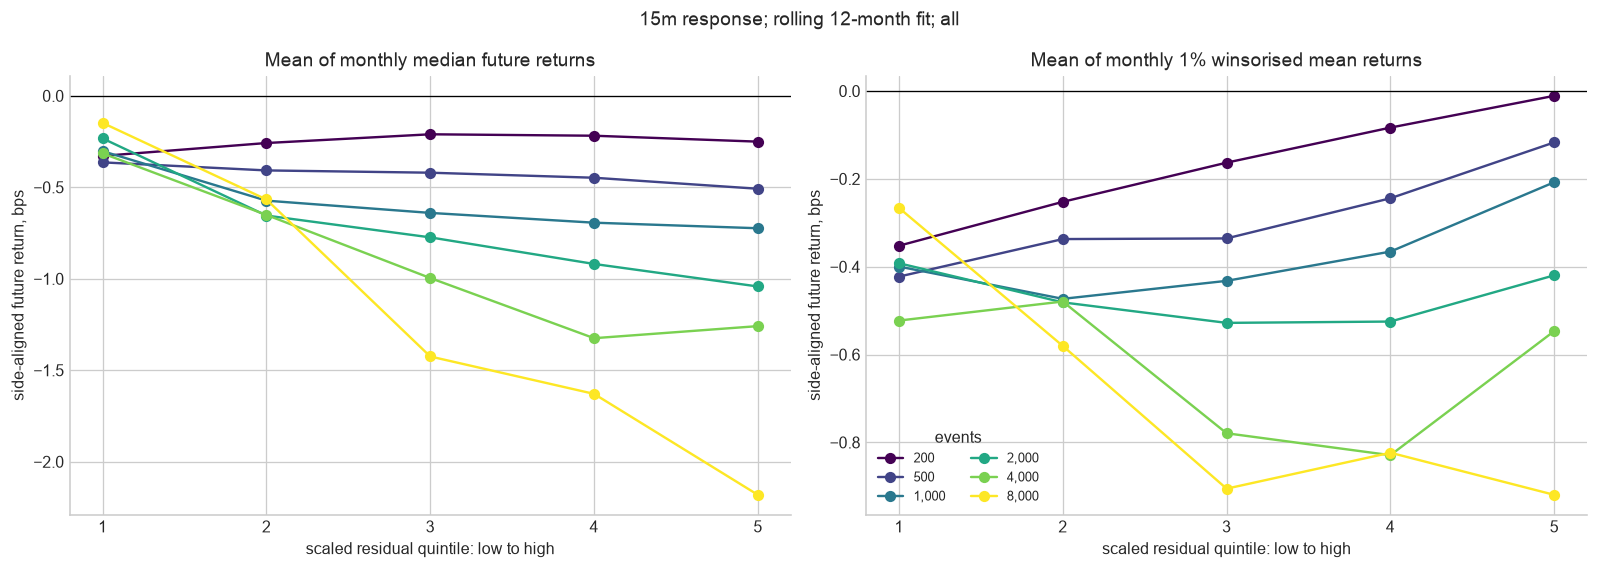

In [22]:
quantile_view = (
    residual_quantiles.filter(
        (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
        (pl.col('horizon_seconds') == IC_HORIZON_SECONDS) &
        (pl.col('side') == IC_SIDE) &
        (pl.col('residual_variant') == RESIDUAL_VARIANT)
    )
    .group_by('n_events', 'residual_quantile')
    .agg(
        pl.col('median_future_return_bps').mean().alias('mean_monthly_median_bps'),
        pl.col('winsorised_mean_future_return_bps').mean()
        .alias('mean_monthly_winsorised_bps'),
    )
    .sort(['n_events', 'residual_quantile'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True)
cmap = plt.get_cmap('viridis')
for index, n_events in enumerate(event_sizes):
    part = quantile_view.filter(pl.col('n_events') == n_events)
    colour = cmap(index / max(1, len(event_sizes)-1))
    axes[0].plot(part['residual_quantile'], part['mean_monthly_median_bps'],
                 'o-', color=colour, label=f'{n_events:,}')
    axes[1].plot(part['residual_quantile'], part['mean_monthly_winsorised_bps'],
                 'o-', color=colour, label=f'{n_events:,}')
for ax, title in zip(
    axes,
    ['Mean of monthly median future returns',
     'Mean of monthly 1% winsorised mean returns']
):
    ax.axhline(0, color='black', lw=.8)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel('scaled residual quintile: low to high')
    ax.set_ylabel('side-aligned future return, bps')
    ax.set_title(title)
axes[1].legend(title='events', fontsize=8, ncol=2)
fig.suptitle(
    f'{horizon_label(IC_HORIZON_SECONDS)} response; '
    f'rolling {IC_TRAINING_WINDOW}-month fit; {IC_SIDE}'
)
plt.tight_layout()
plt.show()

## Residual-response term structure

The left panel is the cumulative side-aligned response from the decision-bar close.
The right panel differences adjacent horizons, making reaction and counterreaction
visible. Because intervals have different lengths, incremental values should be read
as price changes over the labelled interval, not as equal-frequency returns.

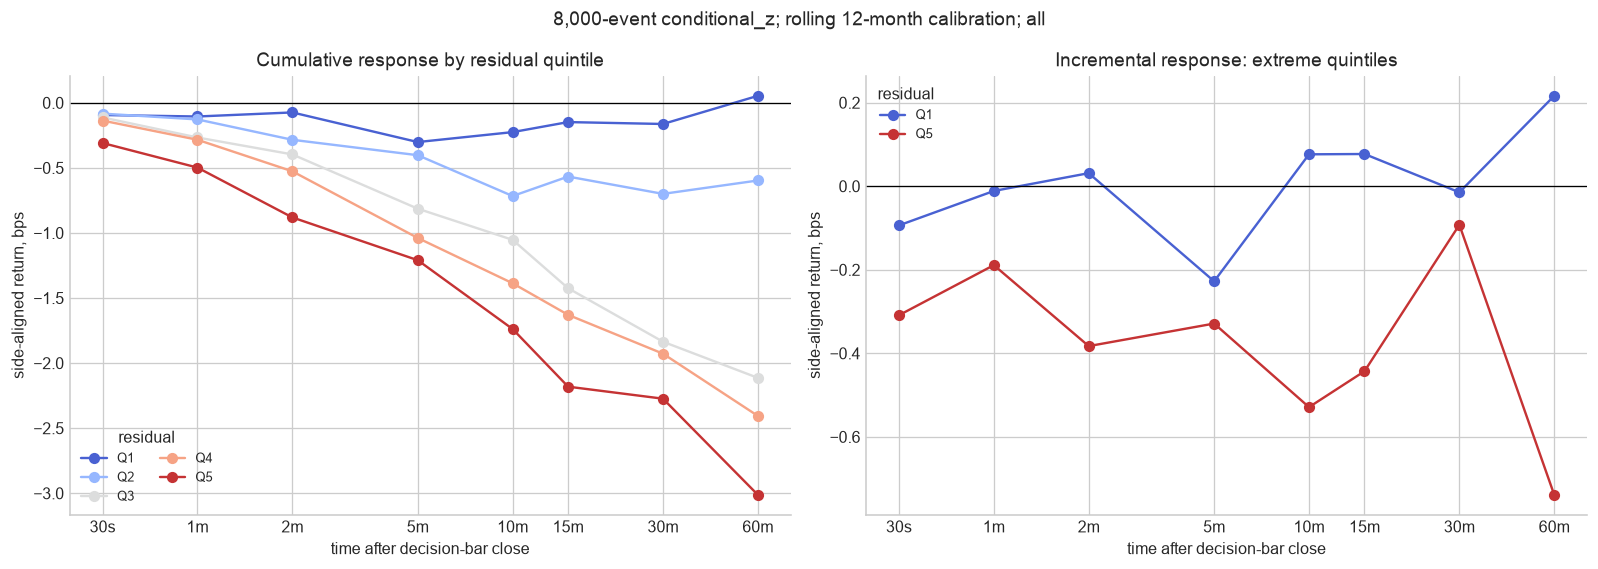

In [23]:
term_structure = (
    residual_quantiles.filter(
        (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
        (pl.col('n_events') == IC_EVENT_SIZE) &
        (pl.col('side') == IC_SIDE) &
        (pl.col('residual_variant') == RESIDUAL_VARIANT)
    )
    .group_by('horizon_seconds', 'residual_quantile')
    .agg(
        pl.col('median_future_return_bps').mean()
        .alias('mean_monthly_median_bps')
    )
    .sort(['residual_quantile', 'horizon_seconds'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
colours = plt.get_cmap('coolwarm')(np.linspace(.05, .95, 5))
for quantile in range(1, 6):
    part = term_structure.filter(
        pl.col('residual_quantile') == quantile
    ).sort('horizon_seconds')
    seconds = part['horizon_seconds'].to_numpy()
    cumulative = part['mean_monthly_median_bps'].to_numpy()
    axes[0].plot(
        seconds, cumulative, 'o-', color=colours[quantile-1],
        label=f'Q{quantile}'
    )
    if quantile in {1, 5}:
        incremental = np.diff(np.r_[0.0, cumulative])
        axes[1].plot(
            seconds, incremental, 'o-', color=colours[quantile-1],
            label=f'Q{quantile}'
        )
for ax in axes:
    ax.axhline(0, color='black', lw=.8)
    ax.set_xscale('log')
    ax.set_xticks(horizons, [horizon_label(h) for h in horizons])
    ax.set_xlabel('time after decision-bar close')
    ax.set_ylabel('side-aligned return, bps')
axes[0].set_title('Cumulative response by residual quintile')
axes[1].set_title('Incremental response: extreme quintiles')
axes[0].legend(title='residual', ncol=2, fontsize=8)
axes[1].legend(title='residual', fontsize=8)
fig.suptitle(
    f'{IC_EVENT_SIZE:,}-event {RESIDUAL_VARIANT}; '
    f'rolling {IC_TRAINING_WINDOW}-month calibration; {IC_SIDE}'
)
plt.tight_layout()
plt.show()

## Buy/sell symmetry of the predictive residual

Both series are side-aligned: negative IC means reversal after excess impact on
that side. A difference between the two lines is therefore a genuine predictive
asymmetry, not merely the sign convention of returns.

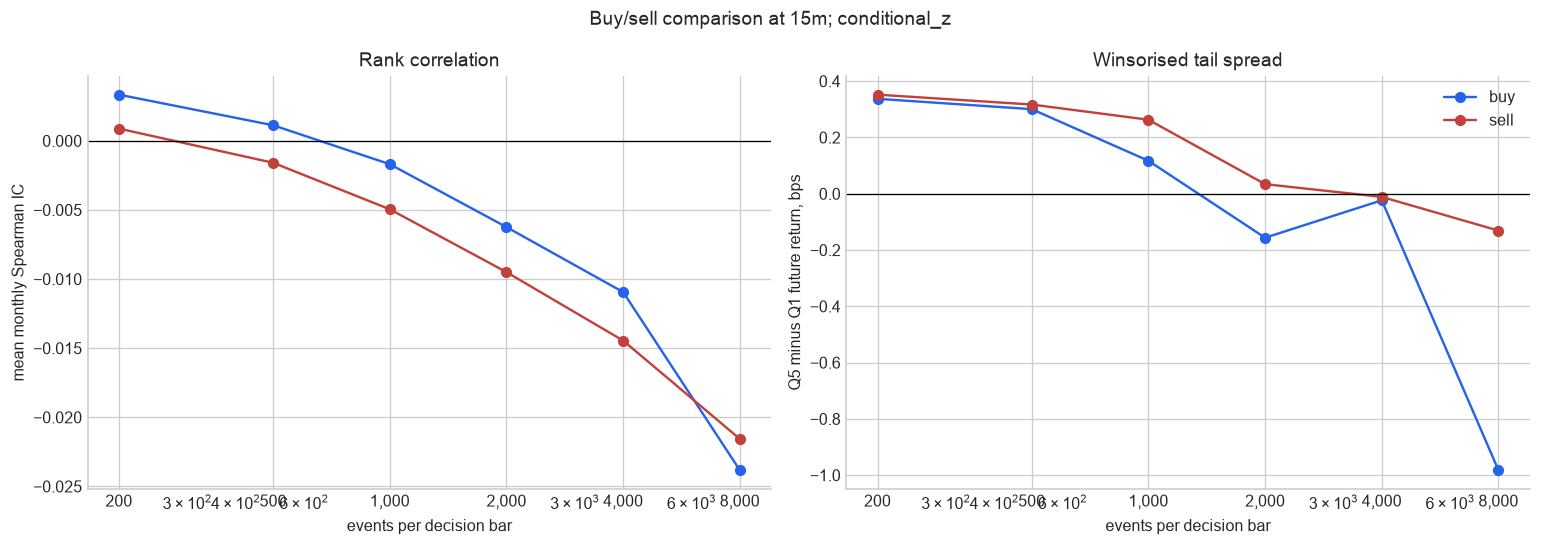

side,n_events,observations,pooled_pearson_ic,mean_monthly_spearman_ic,monthly_spearman_t_stat,negative_spearman_month_fraction,mean_winsorised_top_minus_bottom_bps
str,i64,i64,f64,f64,f64,f64,f64
"""buy""",200,4300226,0.001799,0.003344,4.117351,0.301887,0.337474
"""buy""",500,1716624,0.001749,0.001129,1.126876,0.415094,0.300664
"""buy""",1000,857029,0.000471,-0.001688,-1.501989,0.641509,0.117228
"""buy""",2000,426945,-0.000304,-0.006239,-3.638472,0.679245,-0.156187
"""buy""",4000,209855,-0.002597,-0.010941,-4.931327,0.754717,-0.023229
…,…,…,…,…,…,…,…
"""sell""",500,1739096,0.001622,-0.001585,-1.562043,0.603774,0.317071
"""sell""",1000,870831,0.002576,-0.00495,-3.832711,0.679245,0.263103
"""sell""",2000,436943,0.000497,-0.009496,-4.83107,0.792453,0.034191


In [24]:
side_comparison = residual_ic_summary.filter(
    (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
    (pl.col('horizon_seconds') == IC_HORIZON_SECONDS) &
    (pl.col('residual_variant') == RESIDUAL_VARIANT) &
    pl.col('side').is_in(['buy', 'sell'])
).sort(['side', 'n_events'])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for side_name, colour in [('buy', '#2563eb'), ('sell', '#c2413b')]:
    part = side_comparison.filter(pl.col('side') == side_name)
    axes[0].plot(
        part['n_events'], part['mean_monthly_spearman_ic'], 'o-',
        color=colour, label=side_name
    )
    axes[1].plot(
        part['n_events'], part['mean_winsorised_top_minus_bottom_bps'], 'o-',
        color=colour, label=side_name
    )
for ax in axes:
    ax.axhline(0, color='black', lw=.8)
    ax.set_xscale('log')
    ax.set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
    ax.set_xlabel('events per decision bar')
axes[0].set_ylabel('mean monthly Spearman IC')
axes[0].set_title('Rank correlation')
axes[1].set_ylabel('Q5 minus Q1 future return, bps')
axes[1].set_title('Winsorised tail spread')
axes[1].legend()
fig.suptitle(
    f'Buy/sell comparison at {horizon_label(IC_HORIZON_SECONDS)}; '
    f'{RESIDUAL_VARIANT}'
)
plt.tight_layout()
plt.show()

display(
    side_comparison.select(
        'side', 'n_events', 'observations', 'pooled_pearson_ic',
        'mean_monthly_spearman_ic', 'monthly_spearman_t_stat',
        'negative_spearman_month_fraction',
        'mean_winsorised_top_minus_bottom_bps'
    )
)

## Monthly stability of the selected predictive correlation

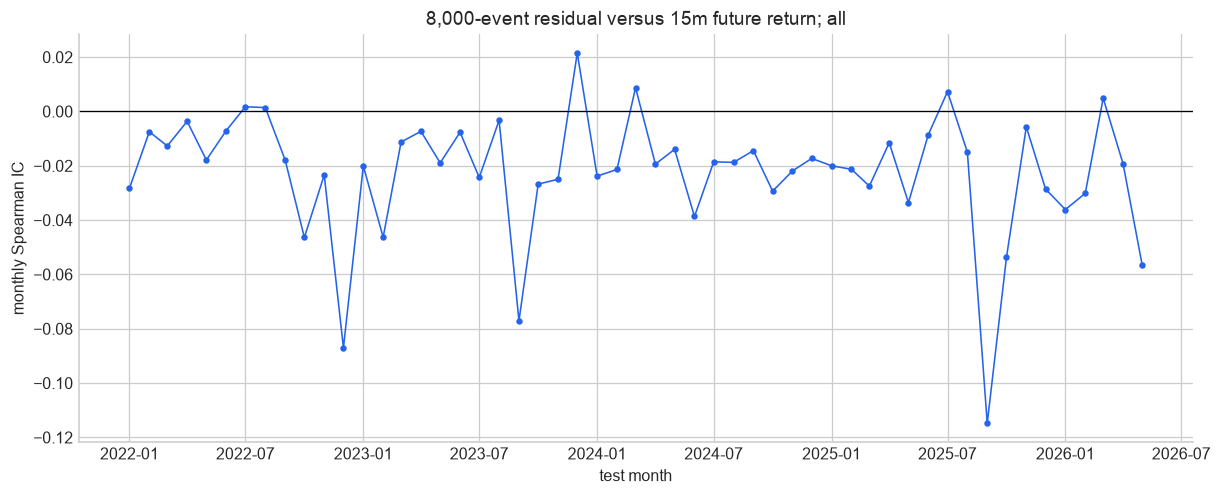

In [25]:
selected_ic = monthly_ic.filter(
    (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
    (pl.col('n_events') == IC_EVENT_SIZE) &
    (pl.col('horizon_seconds') == IC_HORIZON_SECONDS) &
    (pl.col('side') == IC_SIDE) &
    (pl.col('residual_variant') == RESIDUAL_VARIANT)
).sort('calibration_date')
dates = np.array([np.datetime64(value) for value in selected_ic['calibration_date']])

fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.plot(dates, selected_ic['spearman_ic'], 'o-', ms=3, lw=1, color='#2563eb')
ax.axhline(0, color='black', lw=.8)
ax.set_xlabel('test month')
ax.set_ylabel('monthly Spearman IC')
ax.set_title(
    f'{IC_EVENT_SIZE:,}-event residual versus '
    f'{horizon_label(IC_HORIZON_SECONDS)} future return; {IC_SIDE}'
)
plt.show()

## Interpretation and next test

The cross-scale calibration result and the predictive result are separate. A good
impact collapse establishes a stable expectation for contemporaneous response; it
does not by itself establish a trade. The 30-second to 60-minute term structure now
shows whether a residual begins as continuation, becomes reversal, or exhibits a
reaction/counterreaction path. The buy/sell split shows whether that behaviour can
reasonably be pooled.

`conditional_z` is the preferred comparison variable because its centre and scale
are estimated before the test month within side and scaled-pressure state. The raw
`scaled` residual remains available in the controls because it is the more direct
economic quantity and guards against a result manufactured by standardisation.

The activity diagnostics show that the remaining relationship is not just a few
low-pressure surface cells. It survives at bar level, is broadly monotonic,
strengthens in later test periods and is most negative in the high-pressure cells.
Pressure-bin control reduces it at larger event scales but does not remove it.
Consequently, a neutralisation rule should allow a pressure/activity interaction
and must be frozen from past data; it should not be chosen from a pooled smoother.

The activity-dependent-concavity extension is also not yet an acceptable structural
replacement. It improves mean OOS RMSE by only about 0.3% with full-history
training and leaves the residual/activity correlation essentially unchanged. The
post-2021 fit improves RMSE by roughly 1.6% and reduces that correlation somewhat,
but does so with a near-zero $\gamma$, a very small transition parameter $\alpha$
and an inverted event-count pressure exponent. The fitted $b_1$ is negative rather
than the hypothesised positive value. These compensating parameters are evidence
of weak identification and regime dependence, not a stable liquidity mechanism.

The frozen-P&B lag experiment is more informative. The simple previous-impact
coefficient is negative in every chronological calibration, improves every OOS
fold at every event scale, and reduces residual/lag-impulse correlation from
about -0.22 to approximately zero. This is consistent with counterreaction or
decay of the preceding bar's impact. The gain peaks around 1,000--2,000 events and
weakens at longer scales. Previous activity and duration interactions add almost
nothing and are much less well identified, so `lag_impact` remains the preferred
dynamic specification.

The next checks should remain incremental:

1. extend the one-lag result to a small distributed-lag/propagator specification
   and plot the coefficient against both bar lag and elapsed clock time;
2. compare the resulting dynamic residual with raw impact, imbalance, pretrend and ordinary
   short-horizon reversal on exactly the same observations;
3. add calendar-block confidence intervals and control the finite family of
   scale/horizon/side comparisons;
4. add bar-level summaries of endpoint sweep aggression after extending the cache,
   rather than treating fill or price-level counts as aggression;
5. determine whether a useful large-scale residual can be updated on a shorter
   decision clock without mistaking overlap for independent evidence;
6. only then construct entries, overlapping positions and realistic costs;
7. keep June--August 2026 untouched until the specification is frozen.